In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import backend as K
#from sklearn import preprocessing
from importlib import reload
import matplotlib as mpl
import scipy
import os

sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE.model
from tools_for_VAE import utils, vae_functions, generator, model, boxplot, plot

%matplotlib inline
%config InlineBackend.figure_format='retina'

W0526 14:09:57.873939 140201548601152 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
#import cProfile

In [4]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    # Restrict TensorFlow to only allocate 8GB of memory on the first GPU
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=8192)])
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Virtual devices must be set before GPUs have been initialized
        print(e)
        
tf.config.set_soft_device_placement(True)
tf.debugging.set_log_device_placement(True)

conda list

In [5]:
######## Parameters
nb_of_bands = 6
batch_size = 256

input_shape = (59, 59, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]
kernels = [3,3,3,3]

conv_activation = None
dense_activation = None

bands = [0,1,2,3,4,5]

%conda install fftw

%pip install eigency

%pip install cython

## Load data

In [7]:
root_dir_v1 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/test/' # mag cut at 24.5 in r band
#root_dir_v2 = '/pbs/home/b/barcelin/sps_link/data/dc2_test/test_mag_26.5/' # mag cut at 26.5 in r band

In [8]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [83]:
images_noiseless = np.load(root_dir_v1+'img_noiseless_sample_1.npy', mmap_mode = 'c') # artificial augmentation of pixel intensity. Residual from tests, needs to be suppressed
images_blend = np.load(root_dir_v1+'img_cropped_sample_1.npy', mmap_mode = 'c')
psf = np.load(root_dir_v1+'psf_cropped_sample_1.npy', mmap_mode = 'c')
data = pd.read_csv(root_dir_v1+'img_noiseless_data_1.csv')

images_noiseless_train = images_noiseless[:5000]
images_blend_train = images_blend[:5000]
psf_train = psf[:5000]

images_noiseless_val = images_noiseless[5000:7000]
images_blend_val = images_blend[5000:7000]
psf_val = psf[5000:7000]

images_noiseless_test = images_noiseless[7000:8000]
images_blend_test = images_blend[7000:8000]
psf_test = psf[7000:8000]


ell_1 = np.array(data['e1'])
ell_2 = np.array(data['e2'])
shear_1 = np.array(data['shear_1'])
shear_2 = np.array(data['shear_2'])
convergence = np.array(data['convergence'])

ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

e1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence))
e2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence))

e1_train = e1[:5000]
e2_train = e2[:5000]
e_train = np.zeros((5000,2))
e_train[:,0]=e1_train
e_train[:,1]=e2_train
#e_train[:,2]=np.array(data['redshift'])[:5000]

e1_val = e1[5000:7000]
e2_val = e2[5000:7000]
e_val = np.zeros((2000,2))
e_val[:,0]=e1_val
e_val[:,1]=e2_val
#e_val[:,2]=np.array(data['redshift'])[5000:7000]

e1_test = e1[7000:8000]
e2_test = e2[7000:8000]
e_test = np.zeros((1000,2))
e_test[:,0]=e1_test
e_test[:,1]=e2_test
#e_test[:,2]=np.array(data['redshift'])[7000:8000]

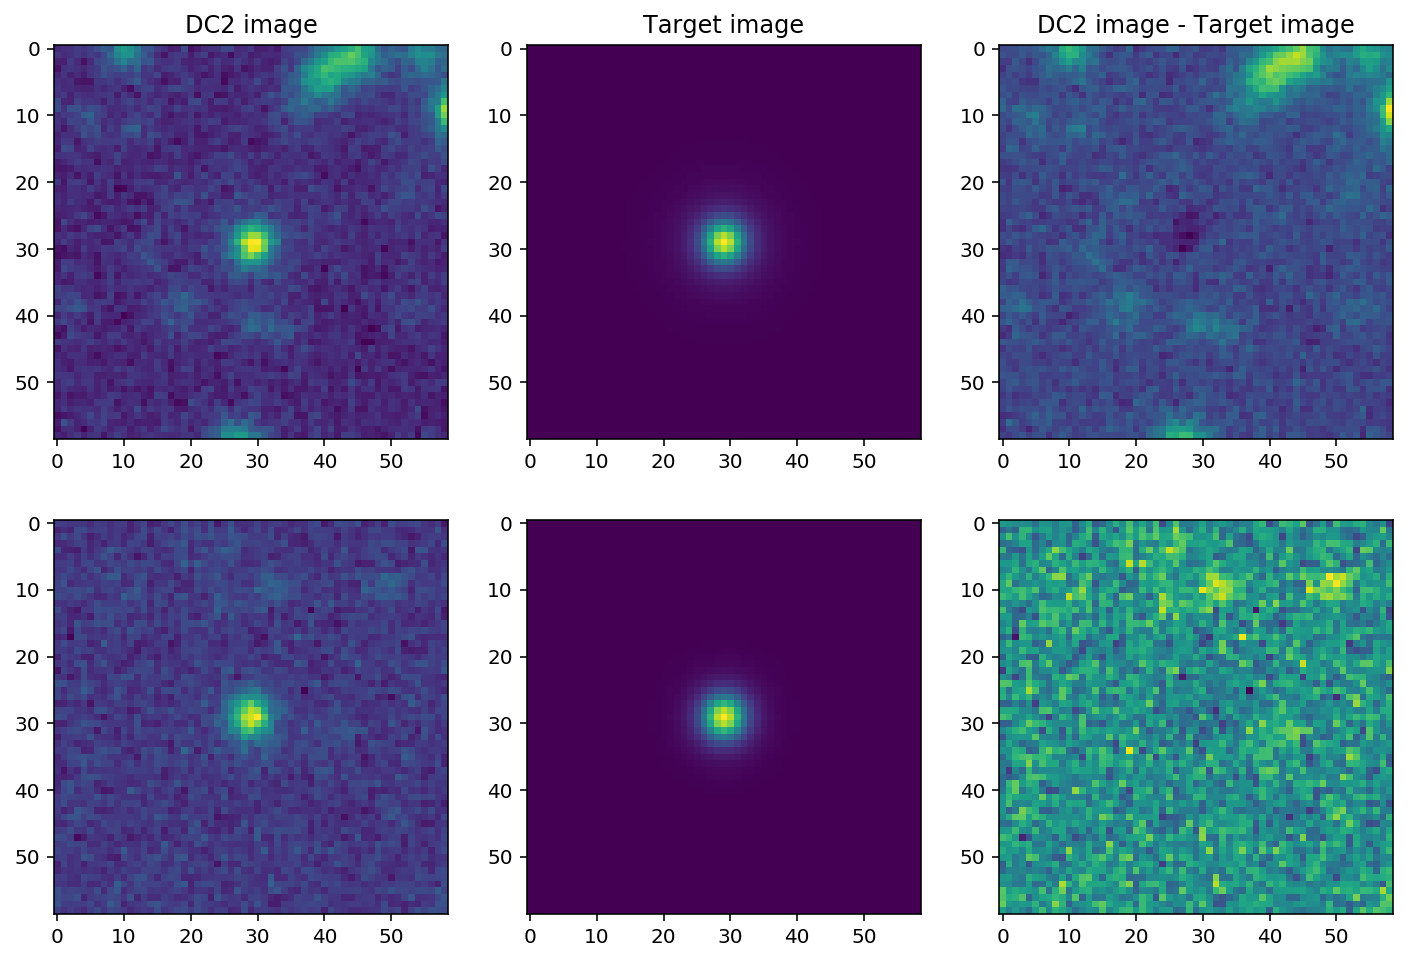

In [15]:
fig, axes = plt.subplots(2,3, figsize = (12, 8))

for i in range (2):
    axes[i,0].imshow(images_blend[i+3,:,:,2])
    axes[i,1].imshow(images_noiseless[i+3,:,:,2])
    axes[i,2].imshow(images_blend[i+3,:,:,2]- images_noiseless[i+3,:,:,2])
    
    if i == 0:
        axes[i,0].set_title('DC2 image')
        axes[i,1].set_title('Target image')
        axes[i,2].set_title('DC2 image - Target image')


In [ ]:
images_blend_train = np.tanh(np.arcsinh(images_blend_train))
images_noiseless_train = np.tanh(np.arcsinh(images_noiseless_train))
psf_train = np.tanh(np.arcsinh(psf_train))

images_blend_val = np.tanh(np.arcsinh(images_blend_val))
images_noiseless_val = np.tanh(np.arcsinh(images_noiseless_val))
psf_val = np.tanh(np.arcsinh(psf_val))

images_blend_test = np.tanh(np.arcsinh(images_blend_test))
images_noiseless_test = np.tanh(np.arcsinh(images_noiseless_test))
psf_test = np.tanh(np.arcsinh(psf_test))

## Load VAE to train deblender

In [6]:
from platform import python_version

print(python_version())

3.6.7


%pip install galsim

In [9]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Multiply, Reshape, Flatten, BatchNormalization, Conv2D, Conv3D, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda,  concatenate
import tensorflow_probability as tfp

In [10]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(encoded_size), scale=1),reinterpreted_batch_ndims=1)

def create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None):
    input_layer_1 = Input(shape=(input_shape)) 
    input_layer_2 = Input(shape=(input_shape)) 

    h = BatchNormalization()(input_layer_1)
    #h = input_layer_1
    h_2 = input_layer_2
    for i in range(len(filters)):
        h_2 = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same')(h_2)
        h_2 = PReLU()(h_2)
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same', strides=(2,2))(h)
        h = PReLU()(h)

        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same')(h)
        h = PReLU()(h)
        h_2 = Conv2D(filters[i], (kernels[i],kernels[i]), activation=None, padding='same', strides=(2,2))(h_2)
        h_2 = PReLU()(h_2)

    h = tf.keras.layers.concatenate([tf.cast(h,tf.float64), tf.cast(h_2,tf.float64)], axis =-1)
    h = Flatten()(h)
    h = PReLU()(h)
    h = Dense(256)(h)
    h = PReLU()(h)
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(32),
                activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(32,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.01))(tf.cast(h,tf.float32))#,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.001)
    
    
    h = PReLU()(h)
    h = Dense(256)(h)
    h = PReLU()(h)
    #h = tf.keras.layers.Lambda(lambda x: tf.signal.ifft(tf.cast(x, tf.complex64), name=None))(h)
    w = int(np.ceil(input_shape[0]/2**(len(filters))))
    h = Dense(w*w*filters[-1], activation=dense_activation)(tf.cast(h,tf.float32))
    h = PReLU()(h)
    h = Reshape((w,w,filters[-1]))(h)
    for i in range(len(filters)-1,-1,-1):
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
        #h = tf.keras.layers.UpSampling2D()(h)
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        h = PReLU()(h)
    h = Conv2D(input_shape[-1], (3,3), activation='sigmoid', padding='same')(h)
    #h = PReLU()(h)
    cropping = int(h.get_shape()[1]-input_shape[0])
    if cropping>0:
        print('in cropping')
        if cropping % 2 == 0:
            h = Cropping2D(cropping/2)(h)
        else:
            h = Cropping2D(((cropping//2,cropping//2+1),(cropping//2,cropping//2+1)))(h)


    model = Model([input_layer_1, input_layer_2],h)

    return model

In [10]:
path_output = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v19/bis/mse/'
net = create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0514 14:52:27.345835 140570902329152 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0514 14:52:27.855951 140570902329152 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [23]:
latest = tf.train.latest_checkpoint(path_output)
net.load_weights(latest)

In [24]:
#### Loss definition
model_loss = 'crossentropy'
if model_loss == 'mse':
    vae_loss = tf.keras.losses.MeanSquaredError()
elif model_loss == 'crossentropy':
    def vae_loss(x, x_decoded_mean):
        xent_loss = K.mean(K.sum(K.binary_crossentropy(x, x_decoded_mean), axis=[1,2,3]))
        #x_res = K.mean(K.sum(K.binary_crossentropy(x, x-x_decoded_mean), axis=[1,2,3]))
        return xent_loss


# Custom metrics
def kl_metric(y_true, y_pred):
    return K.sum(net.losses)
mse = tf.keras.losses.MeanSquaredError()

In [12]:
net.layers[44:]

In [82]:
net.layers[45:]

In [26]:
for i in range (len(net.layers[44:])):
                net.layers[44+i].trainable = False

In [27]:
print("trainable_weights:", len(net.trainable_weights))
print("non_trainable_weights:", len(net.non_trainable_weights))

trainable_weights: 56
non_trainable_weights: 35


In [16]:
# Profile from batches 10 to 15
#log_dir = "/pbs/home/b/barcelin/sps_link/data/log_test/"
#tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
#                                             profile_batch='1, 2')


In [29]:
net.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-4), 
              loss=vae_loss,
              metrics = ['mse', 'acc',kl_metric],
              #experimental_run_tf_function=False,
              )

net.summary()

In [42]:
######## Train the network
## With dataset (faster than directly from generator)
hist = net.fit((images_blend_train, psf_train), images_noiseless_train, epochs=200,#training_ds
                    batch_size=batch_size,
                    verbose=1,
                    shuffle=True,
                    validation_data=((images_blend_val, psf_val), images_noiseless_val),#validation_ds
                    validation_steps=3,)
                    #callbacks=[tb_callback])

Train on 5000 samples, validate on 2000 samples
Epoch 1/200
5000/5000 [==============================] - 20s 4ms/sample - loss: 965.1925 - mean_squared_error: 5.3818e-06 - acc: 0.9358 - kl_metric: 0.4422 - val_loss: 1016.5923 - val_mean_squared_error: 1.6582e-04 - val_acc: 0.9251 - val_kl_metric: 0.4443
Epoch 2/200
5000/5000 [==============================] - 20s 4ms/sample - loss: 965.1694 - mean_squared_error: 5.1339e-06 - acc: 0.9354 - kl_metric: 0.4414 - val_loss: 1016.5422 - val_mean_squared_error: 1.6448e-04 - val_acc: 0.9250 - val_kl_metric: 0.4440
Epoch 3/200
5000/5000 [==============================] - 20s 4ms/sample - loss: 965.1819 - mean_squared_error: 5.2689e-06 - acc: 0.9360 - kl_metric: 0.4423 - val_loss: 1016.5597 - val_mean_squared_error: 1.6476e-04 - val_acc: 0.9243 - val_kl_metric: 0.4424
Epoch 4/200
5000/5000 [==============================] - 20s 4ms/sample - loss: 965.2025 - mean_squared_error: 5.4739e-06 - acc: 0.9353 - kl_metric: 0.4430 - val_loss: 1016.7364 - v

In [46]:
saving_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/test_from_latent_space/'
net.save_weights(saving_path+'cp-{epoch:04d}.ckpt')

In [43]:
output = net([tf.cast(images_blend_test, tf.float32), tf.cast(psf_test, tf.float32)])

In [44]:
output = K.get_value(output)

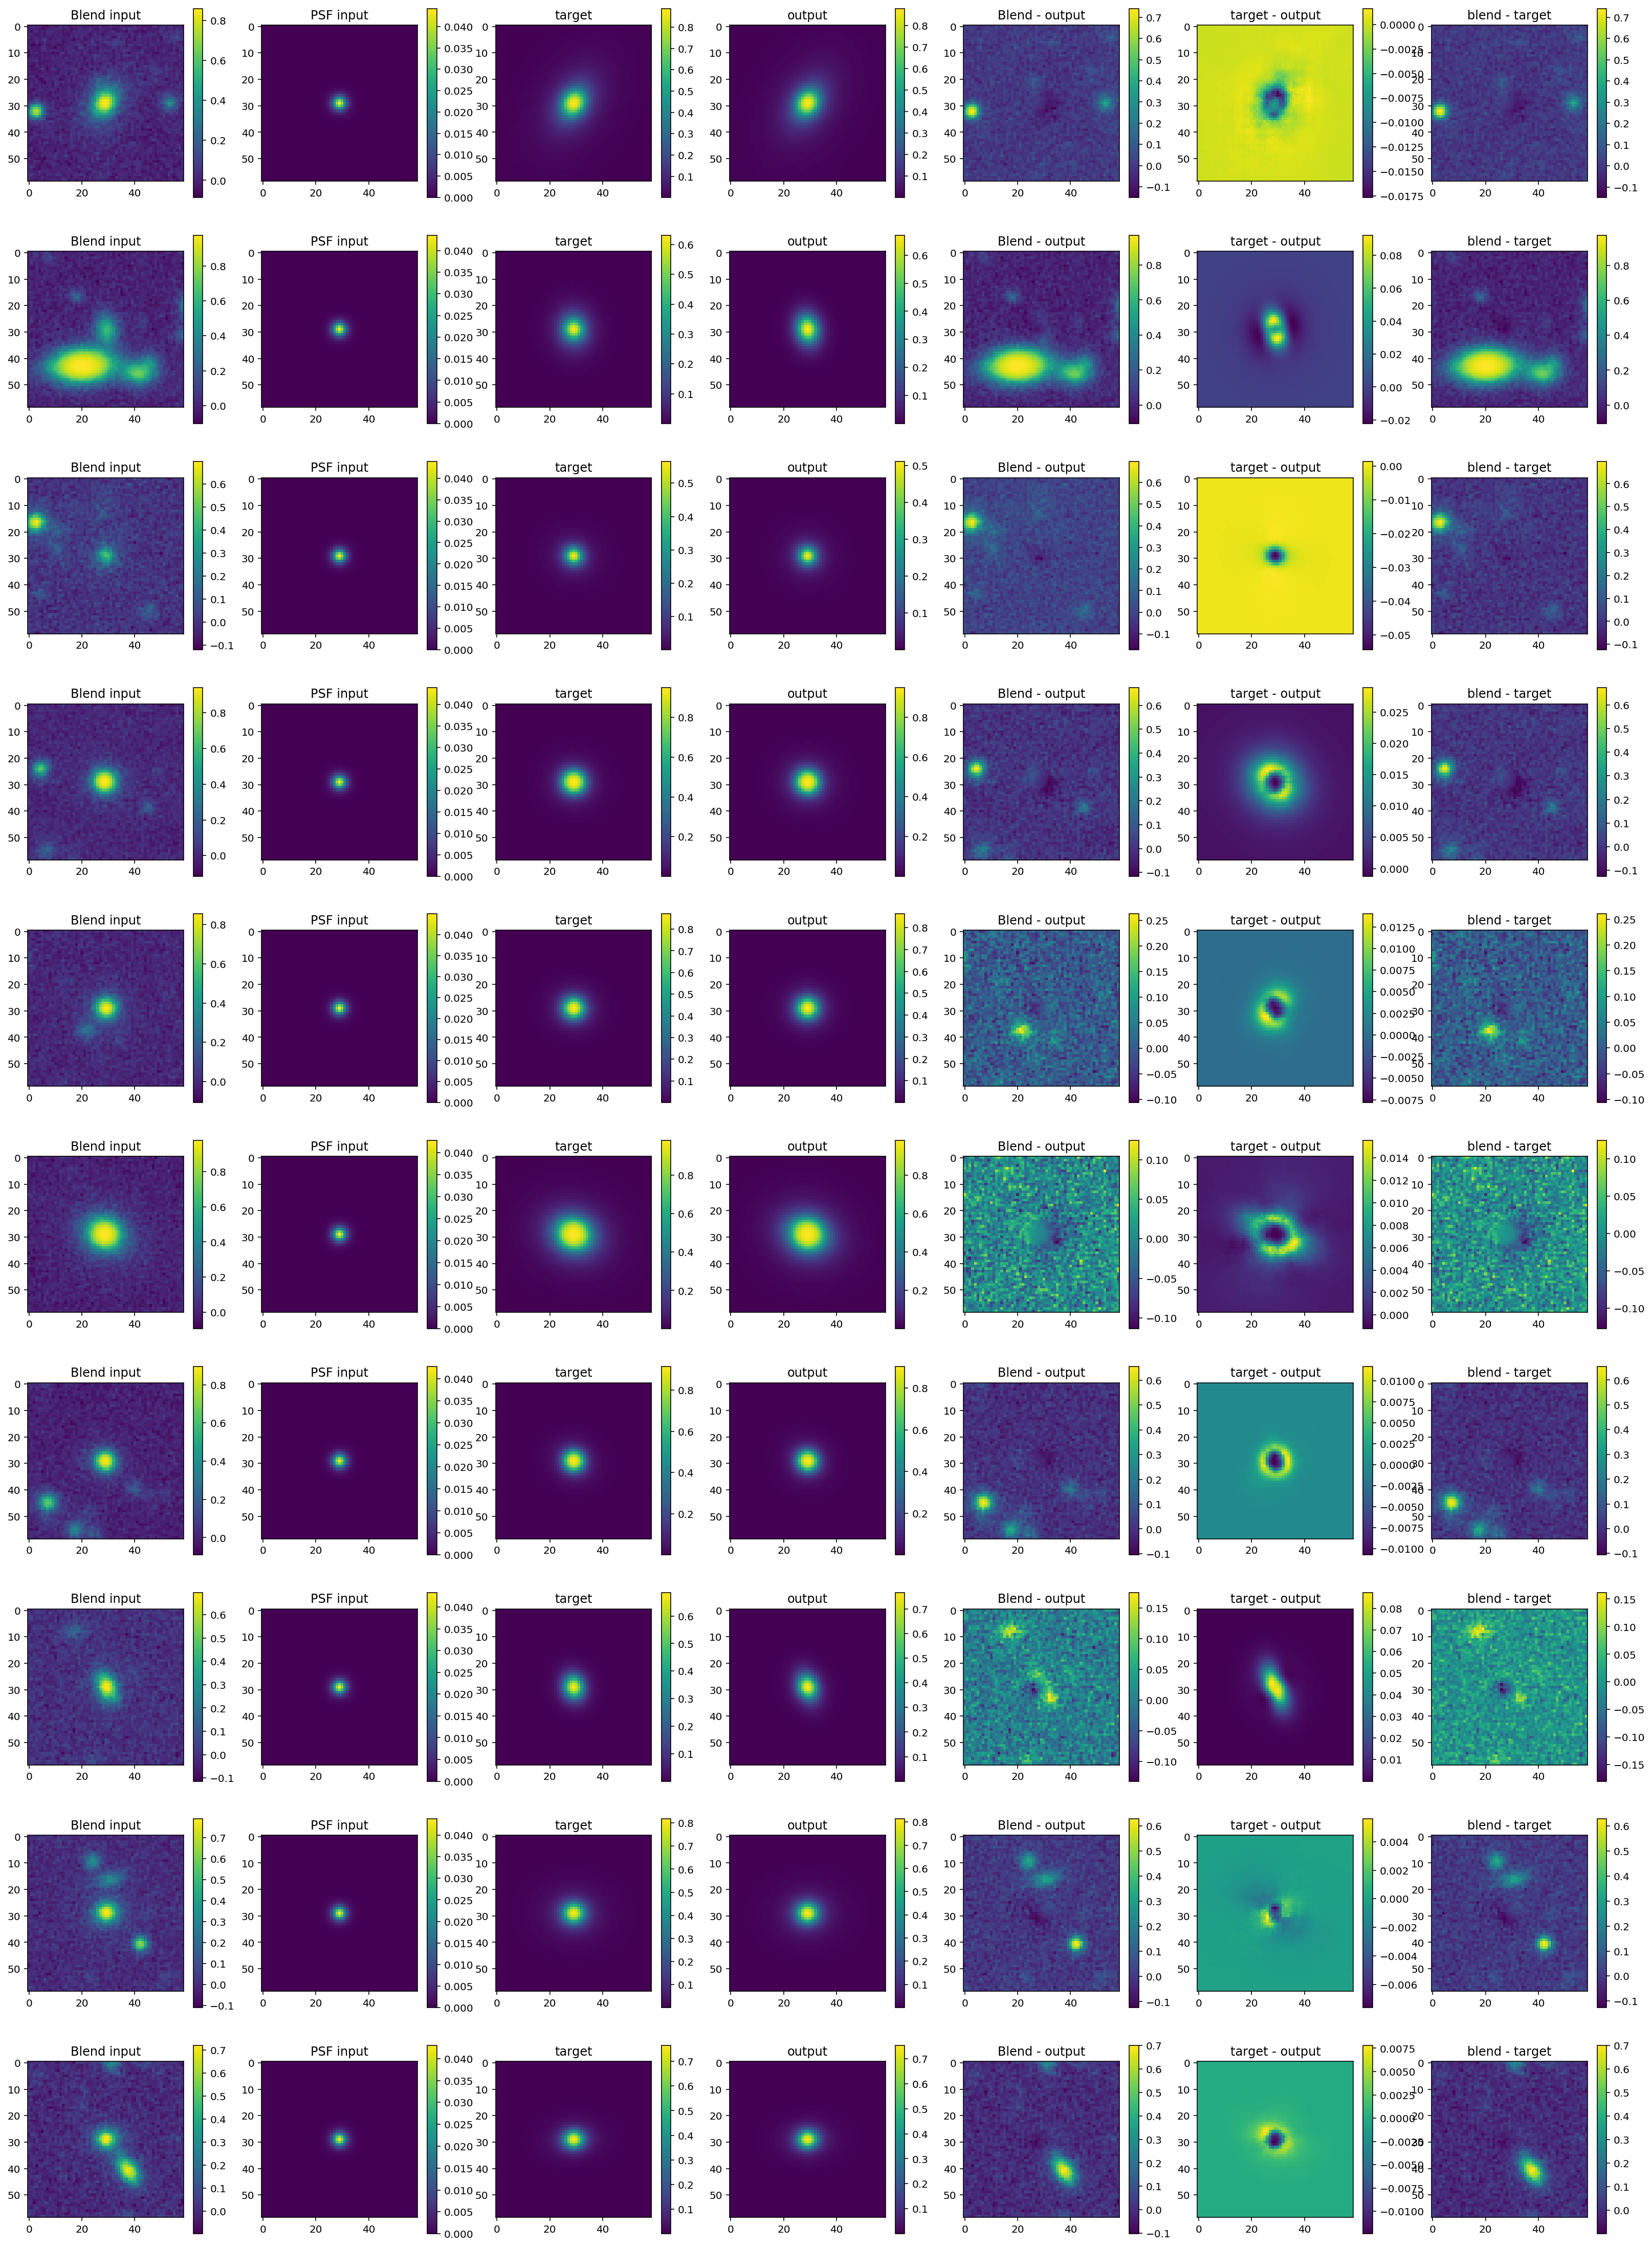

In [45]:
fig, axes = plt.subplots(10,7, figsize = (28, 40))

for i in range (10):
    f1 = axes[i,0].imshow(images_blend_test[i,:,:,2])
    f2 = axes[i,1].imshow(psf_test[i,:,:,2])
    f3 = axes[i,2].imshow(output[i,:,:,2])
    f4 = axes[i,3].imshow(images_noiseless_test[i,:,:,2])
    f5 = axes[i,4].imshow(images_blend_test[i,:,:,2] - output[i,:,:,2])
    f6 = axes[i,5].imshow(images_noiseless_test[i,:,:,2] - output[i,:,:,2])
    f7 = axes[i,6].imshow(images_blend_test[i,:,:,2] - images_noiseless_test[i,:,:,2])
    
    fig.colorbar(f1, ax = axes[i,0])
    fig.colorbar(f2, ax = axes[i,1])
    fig.colorbar(f3, ax = axes[i,2])
    fig.colorbar(f4, ax = axes[i,3])
    fig.colorbar(f5, ax = axes[i,4])
    fig.colorbar(f6, ax = axes[i,5])
    fig.colorbar(f7, ax = axes[i,6])
    
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('PSF input')
    axes[i,2].set_title('output')
    axes[i,3].set_title('target')
    axes[i,4].set_title('Blend - output')
    axes[i,5].set_title('target - output')
    axes[i,6].set_title('blend - target')

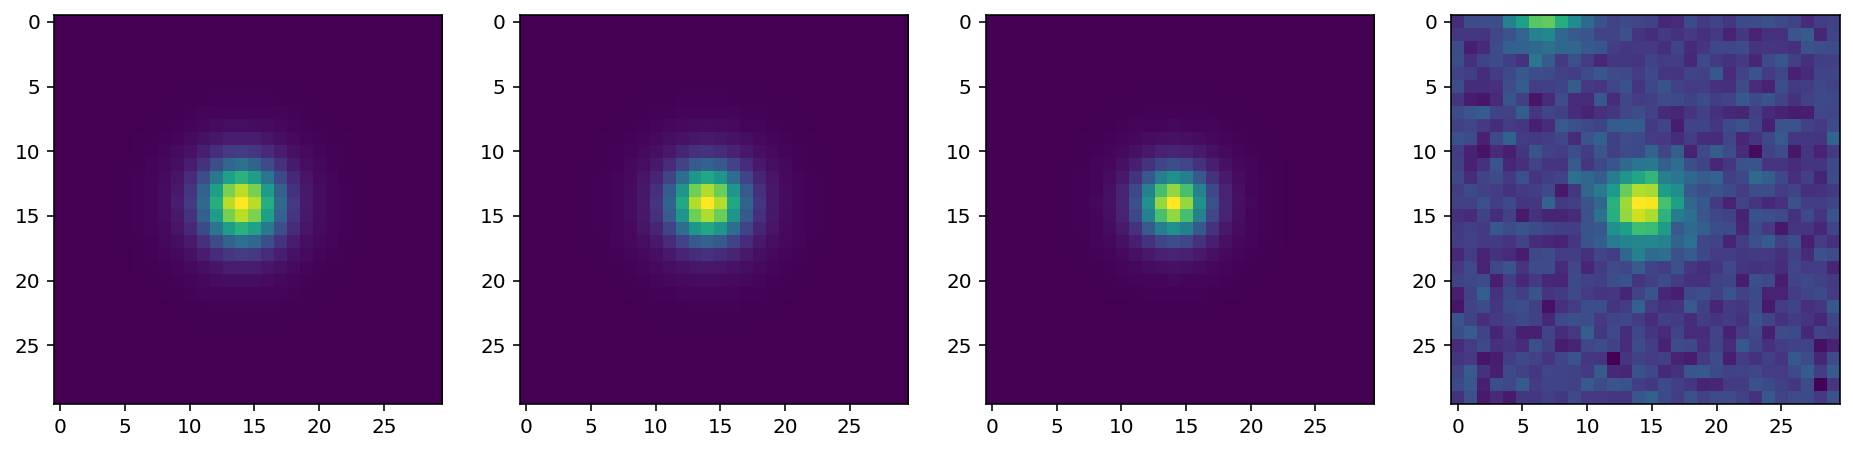

In [71]:
fig, axes = plt.subplots(1,4, figsize = (16,4))

axes[0].imshow(images_noiseless_test[i,15:45,15:45,2])
axes[1].imshow(output[i,15:45,15:45,2])
axes[2].imshow(psf_test[i,15:45,15:45,2])
axes[3].imshow(images_blend_test[i,15:45,15:45,2])

### Test of trained VAE on noisy images

In [9]:
#sys.path.insert(0,'../../../Deblender_VAE/scripts/tools_for_VAE/')
sys.path.insert(0,'../../scripts/tools_for_VAE/')
import tools_for_VAE
import tools_for_VAE.generator as generator
import tools_for_VAE.utils as utils
import tools_for_VAE.vae_functions as vae_functions

In [10]:
path_output = '/pbs/home/b/barcelin/sps_link/TFP/weights/test_dc2/v_vae_psf_noisy/mse/'

In [11]:
net = tools_for_VAE.model.create_model_wo_ls_peak_pooling_vae_3(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0526 14:16:41.927666 140201548601152 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0526 14:16:42.990125 140201548601152 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [12]:
latest = tf.train.latest_checkpoint(path_output)
net.load_weights(latest)

In [21]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/'
list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test/')) if x.startswith(os.path.join(images_dir,'test/')+'img_noiseless_sample')]#mag_24.5

test_generator = generator.BatchGenerator_dc2_deconv_vae_noisy(bands, 
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='validation',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [24]:
test = test_generator.__getitem__(3)

images_blend_test, psf_test = test[0]
images_noiseless_test = test[1]

In [25]:
output = net([tf.cast(images_blend_test, tf.float32), tf.cast(psf_test, tf.float32)])
output = K.get_value(output)

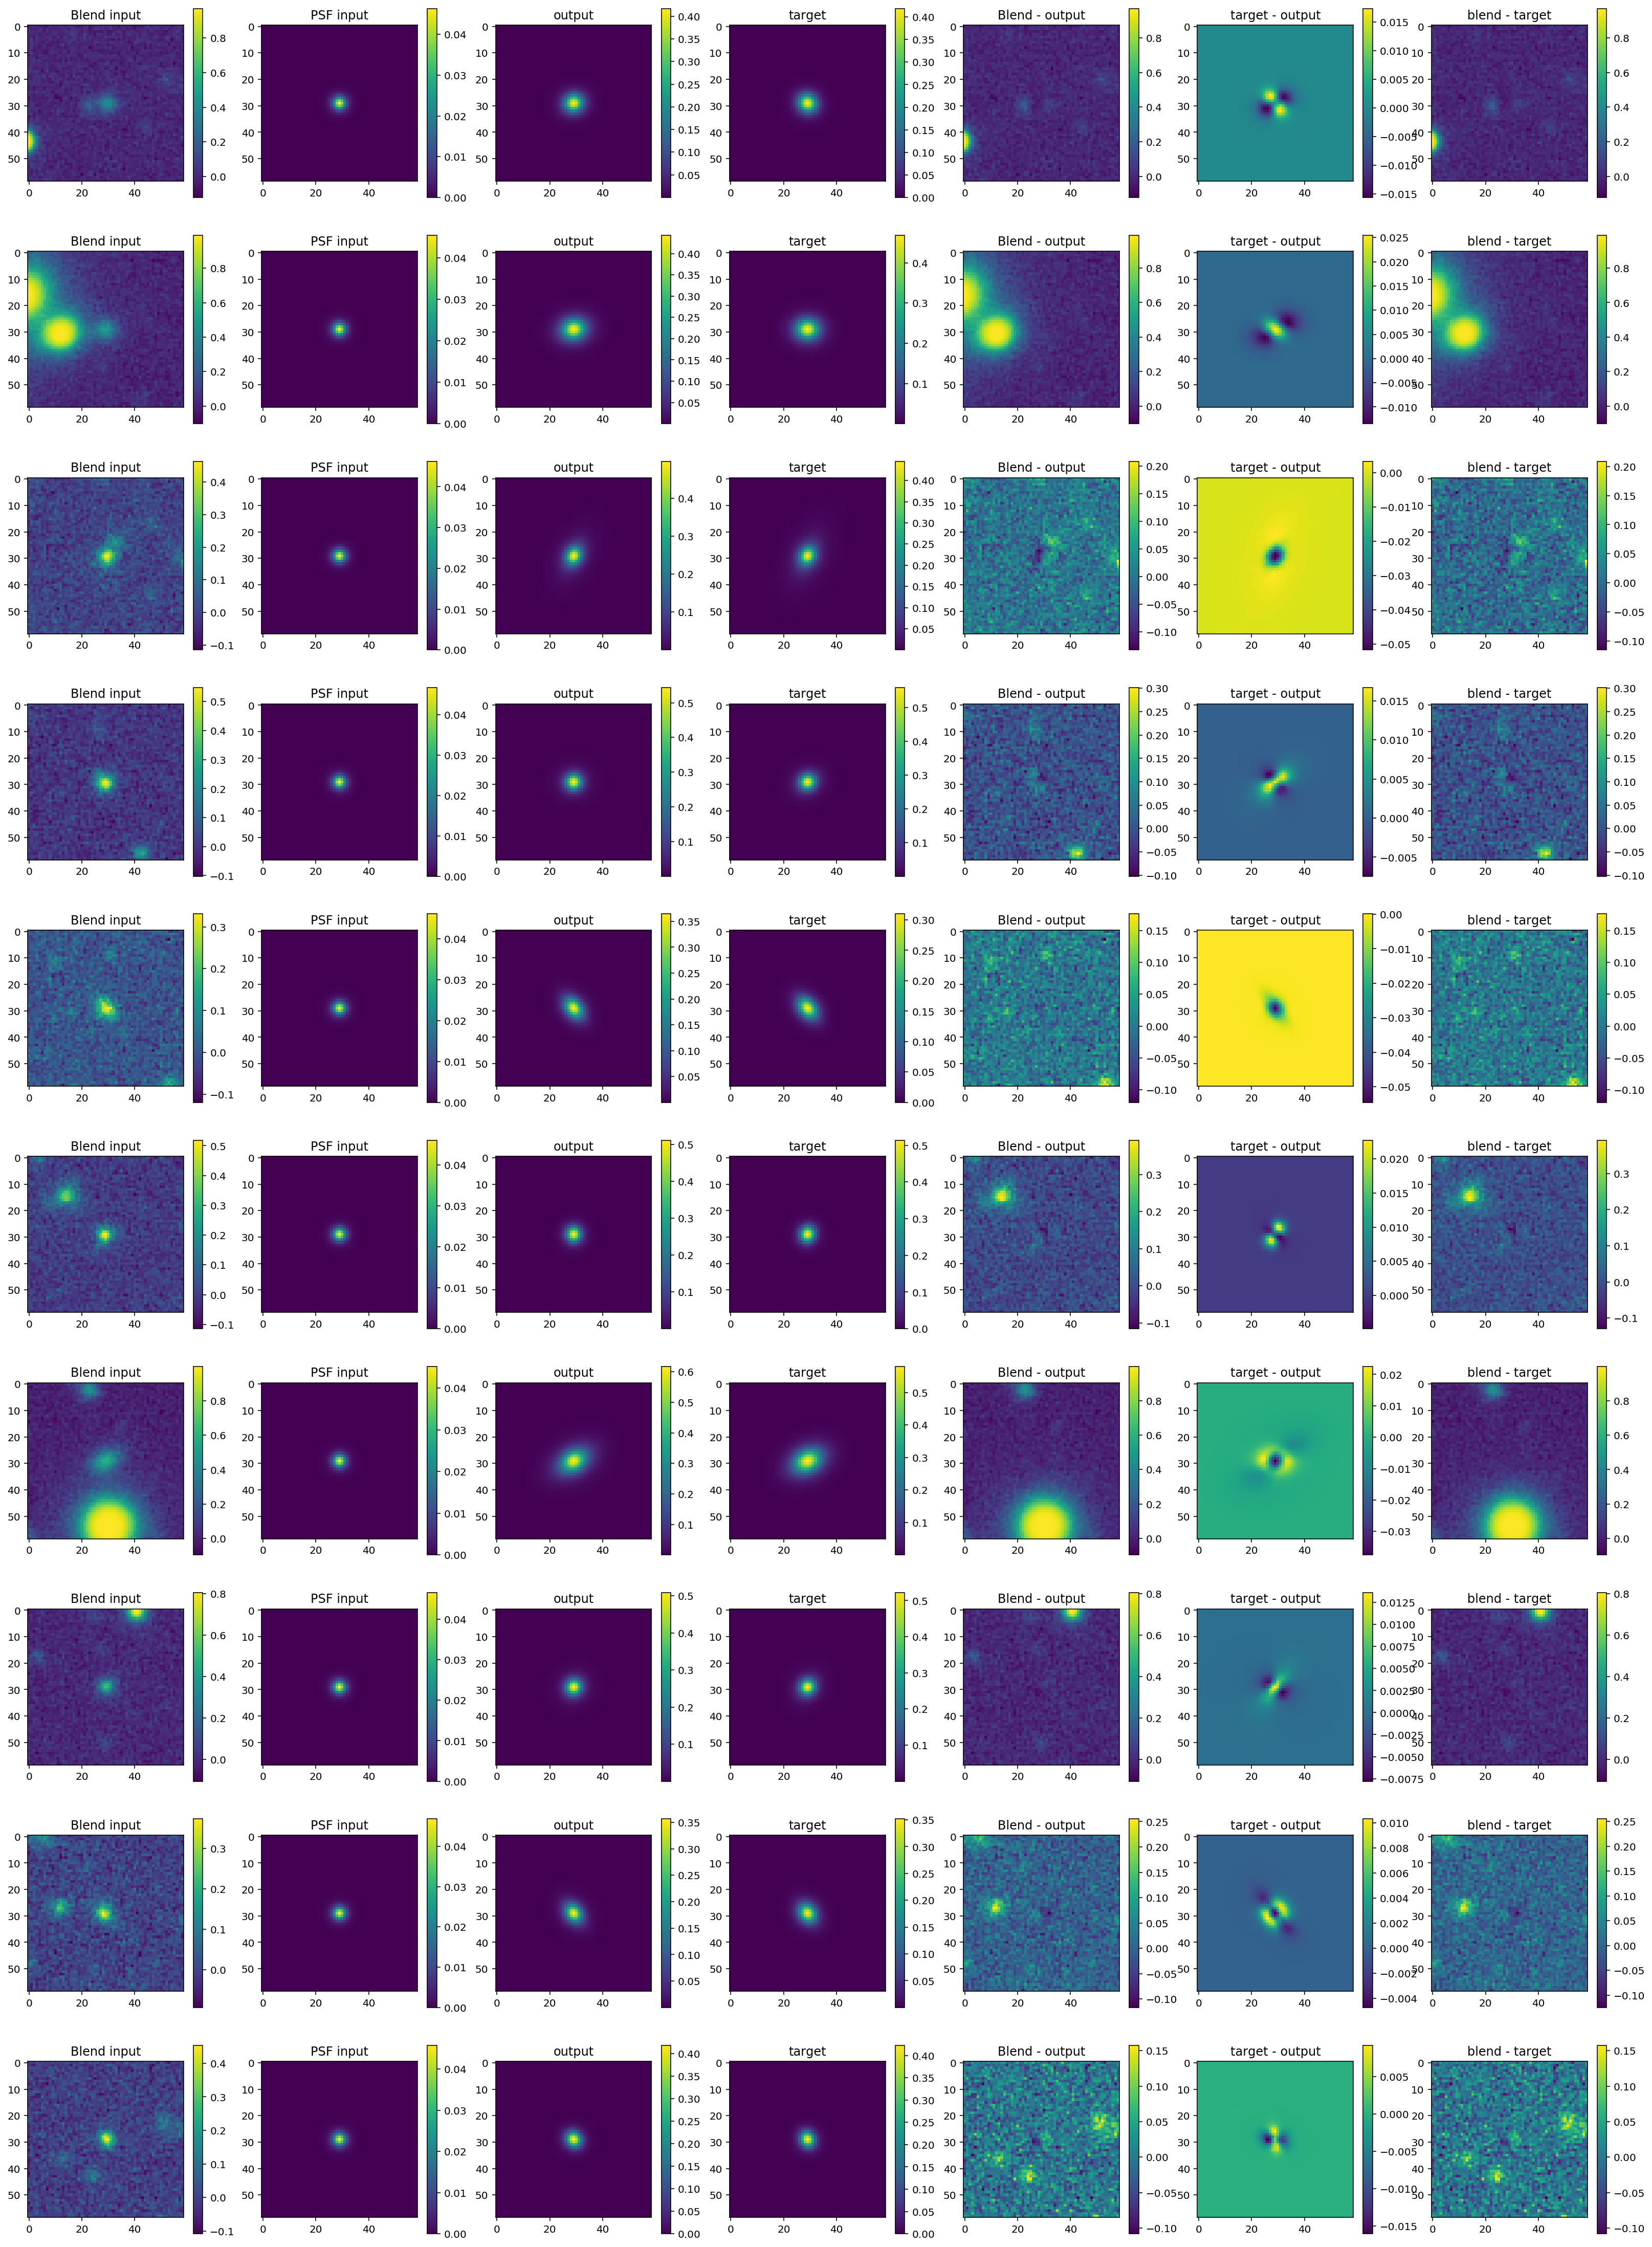

In [26]:
fig, axes = plt.subplots(10,7, figsize = (28, 40))

for i in range (10):
    f1 = axes[i,0].imshow(images_blend_test[i,:,:,2])
    f2 = axes[i,1].imshow(psf_test[i,:,:,2])
    f3 = axes[i,2].imshow(output[i,:,:,2])
    f4 = axes[i,3].imshow(images_noiseless_test[i,:,:,2])
    f5 = axes[i,4].imshow(images_blend_test[i,:,:,2] - output[i,:,:,2])
    f6 = axes[i,5].imshow(images_noiseless_test[i,:,:,2] - output[i,:,:,2])
    f7 = axes[i,6].imshow(images_blend_test[i,:,:,2] - images_noiseless_test[i,:,:,2])
    
    fig.colorbar(f1, ax = axes[i,0])
    fig.colorbar(f2, ax = axes[i,1])
    fig.colorbar(f3, ax = axes[i,2])
    fig.colorbar(f4, ax = axes[i,3])
    fig.colorbar(f5, ax = axes[i,4])
    fig.colorbar(f6, ax = axes[i,5])
    fig.colorbar(f7, ax = axes[i,6])
    
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('PSF input')
    axes[i,2].set_title('output')
    axes[i,3].set_title('target')
    axes[i,4].set_title('Blend - output')
    axes[i,5].set_title('target - output')
    axes[i,6].set_title('blend - target')

Denorm outputs and input images

In [27]:
images_blend_test_denorm = np.sinh(np.arctanh(images_blend_test))
images_noiseless_test_denorm = np.sinh(np.arctanh(images_noiseless_test))
output_denorm = np.sinh(np.arctanh(output))

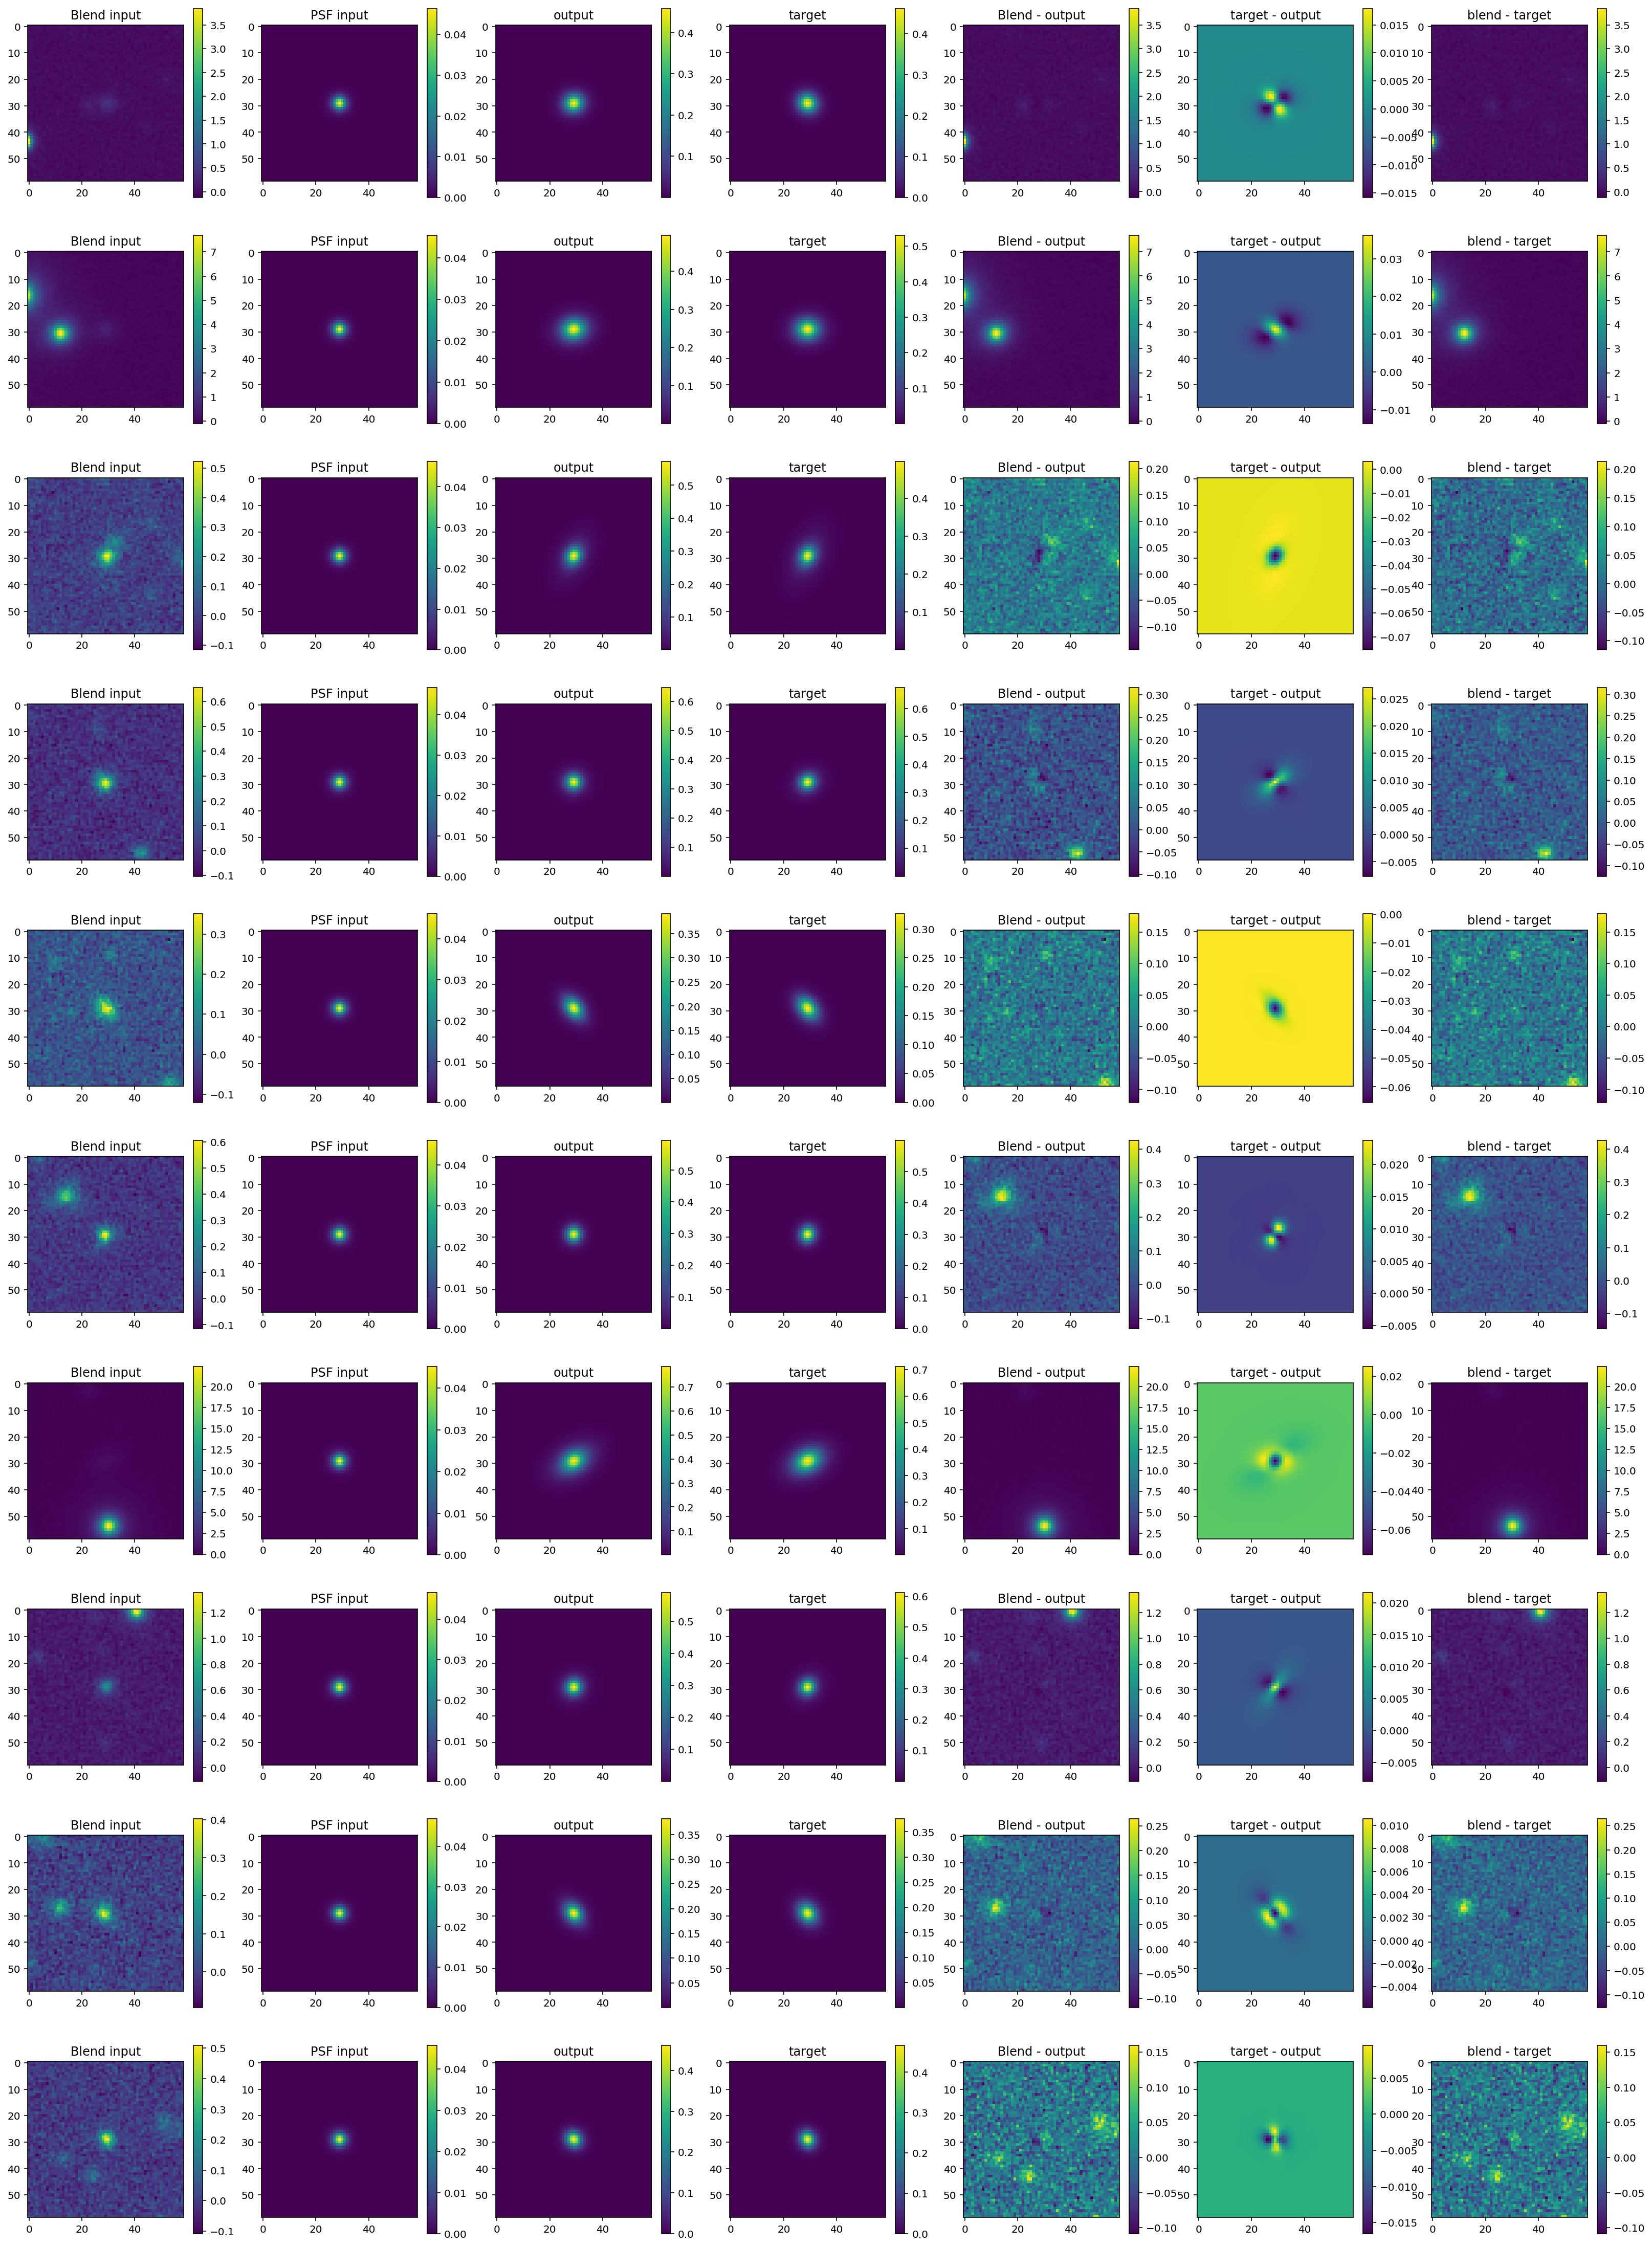

In [28]:
fig, axes = plt.subplots(10,7, figsize = (28, 40))

for i in range (10):
    f1 = axes[i,0].imshow(images_blend_test_denorm[i,:,:,2])
    f2 = axes[i,1].imshow(psf_test[i,:,:,2])
    f3 = axes[i,2].imshow(output_denorm[i,:,:,2])
    f4 = axes[i,3].imshow(images_noiseless_test_denorm[i,:,:,2])
    f5 = axes[i,4].imshow(images_blend_test_denorm[i,:,:,2] - output_denorm[i,:,:,2])
    f6 = axes[i,5].imshow(images_noiseless_test_denorm[i,:,:,2] - output_denorm[i,:,:,2])
    f7 = axes[i,6].imshow(images_blend_test_denorm[i,:,:,2] - images_noiseless_test_denorm[i,:,:,2])
    
    fig.colorbar(f1, ax = axes[i,0])
    fig.colorbar(f2, ax = axes[i,1])
    fig.colorbar(f3, ax = axes[i,2])
    fig.colorbar(f4, ax = axes[i,3])
    fig.colorbar(f5, ax = axes[i,4])
    fig.colorbar(f6, ax = axes[i,5])
    fig.colorbar(f7, ax = axes[i,6])
    
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('PSF input')
    axes[i,2].set_title('output')
    axes[i,3].set_title('target')
    axes[i,4].set_title('Blend - output')
    axes[i,5].set_title('target - output')
    axes[i,6].set_title('blend - target')

W0526 15:40:00.987519 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:40:01.009167 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:40:01.020307 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:40:01.031770 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:40:01.043699 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:40:01.051613 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:40:01.086376 140201

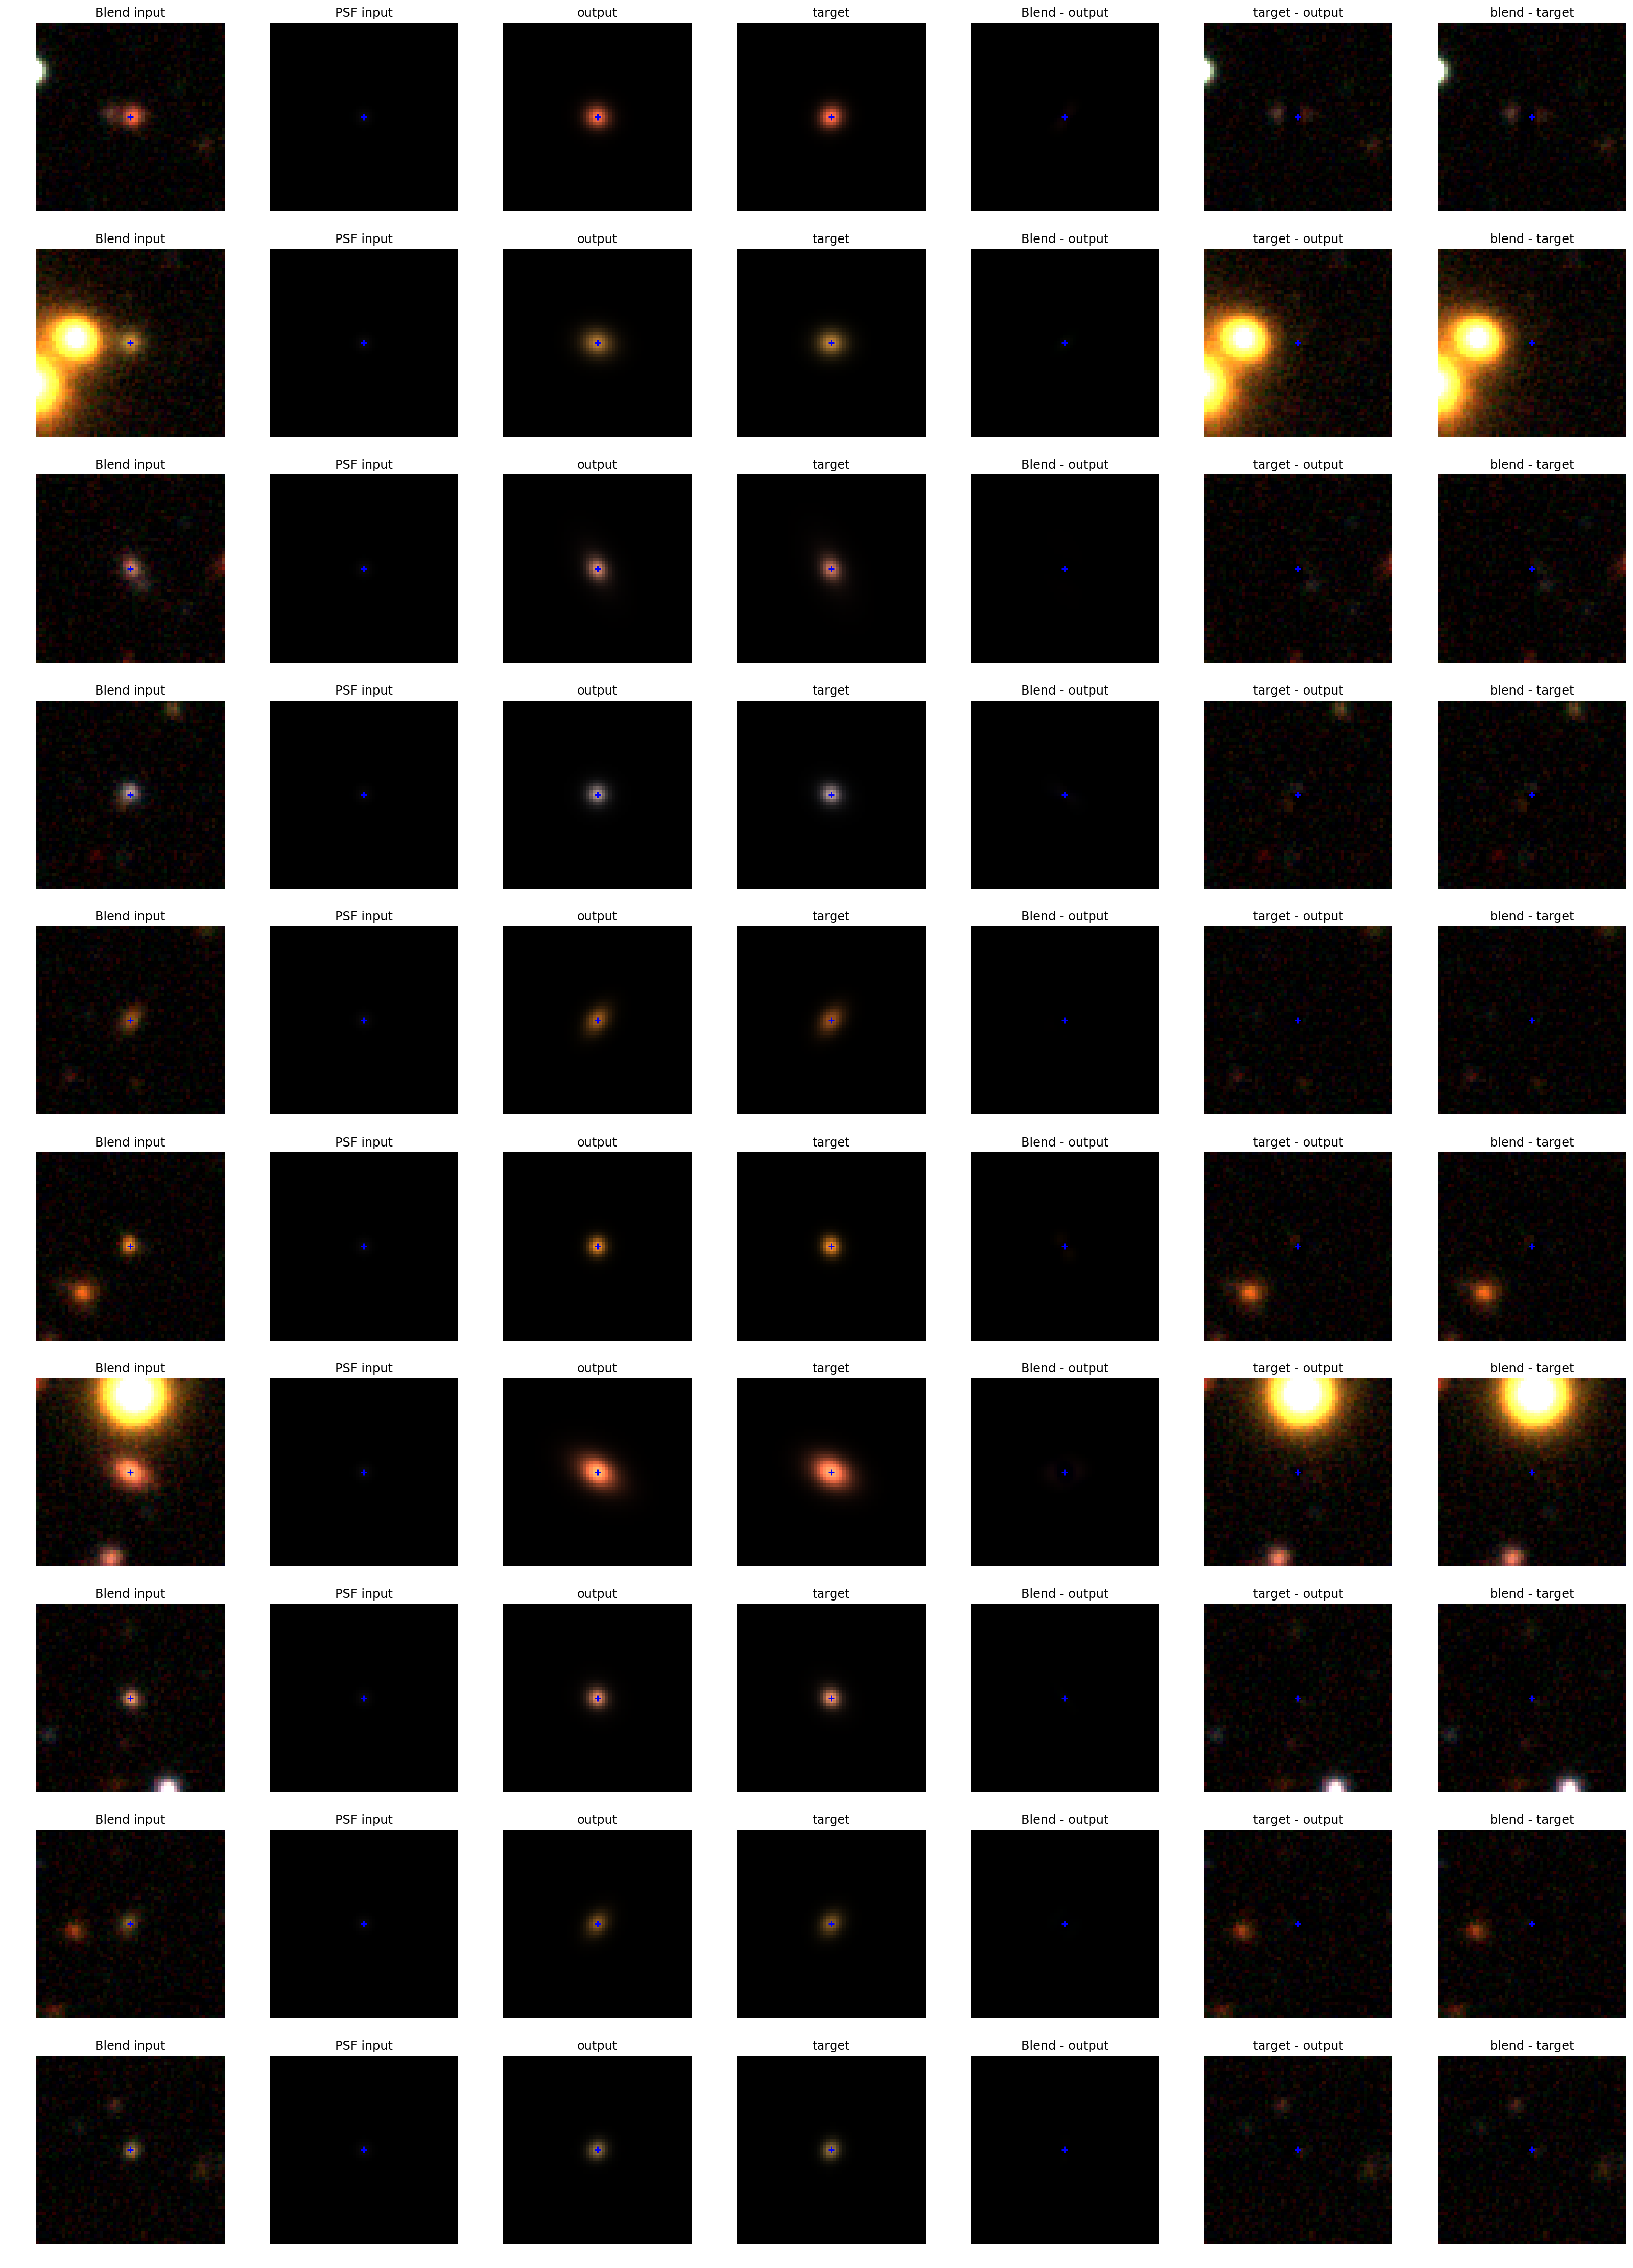

In [41]:
fig, axes = plt.subplots(10,7, figsize = (28, 40))


for i in range (10):
    #clipping_value = np.max(images_blend_test_denorm[i,:,:,])
    
    #axes[i,0].imshow(images_blend_test_denorm[i,:,:,2])
    plot.plot_rgb(images_blend_test_denorm[i], bands = [3,2,1],ax= axes[i,0], band_first= False,zoom = 1,)
    #axes[i,1].imshow(psf_test[i,:,:,2])
    plot.plot_rgb(psf_test[i], bands = [3,2,1],ax= axes[i,1], band_first= False,zoom = 1,)
    #axes[i,2].imshow(output_denorm[i,:,:,2])
    plot.plot_rgb(output_denorm[i], bands = [3,2,1],ax= axes[i,2], band_first= False,zoom = 1,)
    #axes[i,3].imshow(images_noiseless_test_denorm[i,:,:,2])
    plot.plot_rgb(images_noiseless_test_denorm[i], bands = [3,2,1],ax= axes[i,3], band_first= False,zoom = 1,)
    #axes[i,4].imshow(images_blend_test_denorm[i,:,:,2] - output_denorm[i,:,:,2])
    plot.plot_rgb(images_noiseless_test_denorm[i]- output_denorm[i], bands = [3,2,1],ax= axes[i,4], band_first= False,zoom = 1,)
    #axes[i,5].imshow(images_noiseless_test_denorm[i,:,:,2] - output_denorm[i,:,:,2])
    plot.plot_rgb(images_blend_test_denorm[i]- output_denorm[i], bands = [3,2,1],ax= axes[i,5], band_first= False,zoom = 1,)
    #axes[i,6].imshow(images_blend_test_denorm[i,:,:,2] - images_noiseless_test_denorm[i,:,:,2])
    plot.plot_rgb(images_blend_test_denorm[i]- images_noiseless_test_denorm[i], bands = [3,2,1],ax= axes[i,6], band_first= False,zoom = 1,)
        
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('PSF input')
    axes[i,2].set_title('output')
    axes[i,3].set_title('target')
    axes[i,4].set_title('Blend - output')
    axes[i,5].set_title('target - output')
    axes[i,6].set_title('blend - target')

W0526 15:46:13.074540 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:46:13.079433 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:46:13.082334 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:46:13.085592 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:46:13.089813 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:46:13.095811 140201548601152 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0526 15:46:13.099734 140201

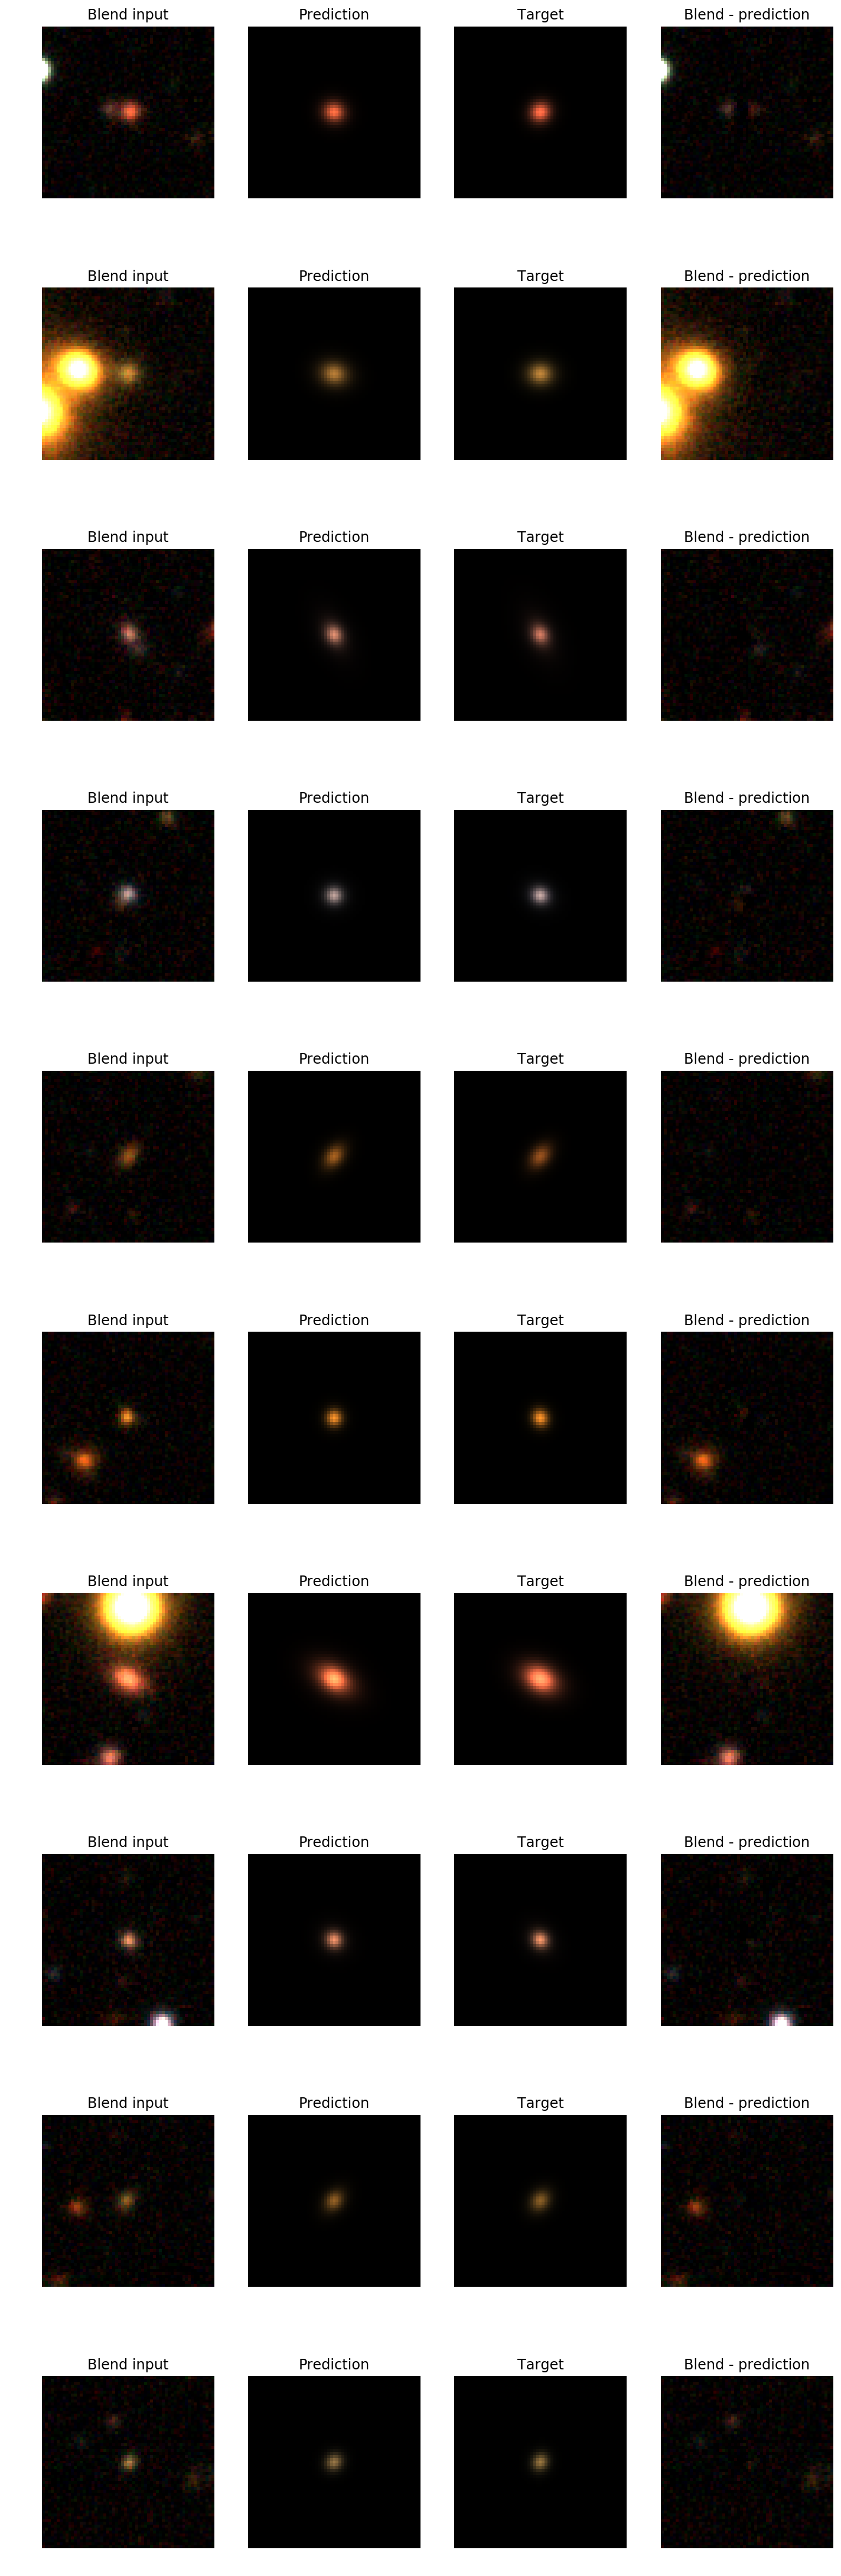

In [45]:
fig, axes = plt.subplots(10,4, figsize = (12, 40))


for i in range (10):
    plot.plot_rgb(images_blend_test_denorm[i], bands = [3,2,1],ax= axes[i,0], band_first= False,zoom = 1,)
    plot.plot_rgb(output_denorm[i], bands = [3,2,1],ax= axes[i,1], band_first= False,zoom = 1,)
    plot.plot_rgb(images_noiseless_test_denorm[i], bands = [3,2,1],ax= axes[i,2], band_first= False,zoom = 1,)
    plot.plot_rgb(images_blend_test_denorm[i]- output_denorm[i], bands = [3,2,1],ax= axes[i,3], band_first= False,zoom = 1,)
        
    axes[i,0].set_title('Blend input')
    axes[i,1].set_title('Prediction')
    axes[i,2].set_title('Target')
    axes[i,3].set_title('Blend - prediction')

## Image reconstruction metrics from https://github.com/LSSTDESC/BlendingToolKit/blob/main/btk/metrics.py

In [21]:
import skimage
#import skimage.metrics

KeyboardInterrupt: 

In [26]:
mse = skimage.metrics.mean_squared_error(images_noiseless, output)
print(mse)

AttributeError: module 'skimage' has no attribute 'metrics'

In [ ]:
psnr = skimage.metrics.peak_signal_noise_ratio(images_noiseless, output, data_range=np.max(images_noiseless))
print(psnr)

In [ ]:
ssim = skimage.metrics.structural_similarity(images_noiseless, output, multichannel = True)
print(ssim)

### Simple network to obtain ellipticity parameters

In [11]:
vae = create_model_wo_ls_peak_pooling_vae(input_shape, latent_dim, hidden_dim, filters, kernels, final_dim, conv_activation=None, dense_activation=None)

W0522 15:36:42.021588 139659305862976 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/resource_variable_ops.py:1635: calling BaseResourceVariable.__init__ (from tensorflow.python.ops.resource_variable_ops) with constraint is deprecated and will be removed in a future version.
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
W0522 15:36:42.531333 139659305862976 deprecation.py:506] From /sps/lsst/users/barcelin/miniconda/envs/singularity5/lib/python3.6/site-packages/tensorflow_core/python/ops/linalg/linear_operator_lower_triangular.py:158: calling LinearOperator.__init__ (from tensorflow.python.ops.linalg.linear_operator) with graph_parents is deprecated and will be removed in a future version.
Instructions for updating:
Do not pass `graph_parents`.  They will  no longer be used.


in cropping


In [12]:
vae.load_weights('/sps/lsst/users/barcelin/TFP/weights/test_dc2/test_from_latent_space/cp-{epoch:04d}.ckpt')

In [13]:
vae.layers[44]

In [14]:
encoder = Model([vae.layers[0].input,vae.layers[2].input], vae.layers[42].output) #vae.layers[44].output[0]

In [15]:
encoder.output

<tf.Tensor 'dense_1/BiasAdd:0' shape=(?, 560) dtype=float64>

In [62]:
encoder.summary()

Model: "model_8"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 59, 59, 6)    24          input_1[0][0]                    
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 30, 30, 32)   1760        batch_normalization[0][0]        
____________________________________________________________________________________________

In [35]:
input_layer_1 = Input(shape=(input_shape)) 
input_layer_2 = Input(shape=(input_shape)) 

out = encoder([input_layer_1,input_layer_2])
print(out)

Tensor("model_1_3/dense_1/BiasAdd:0", shape=(?, 560), dtype=float64)


In [75]:
tfd = tfp.distributions
tfb = tfp.bijectors
encoded_size = 32
prior = tfd.Independent(tfd.Normal(loc=tf.zeros(32), scale=1.),reinterpreted_batch_ndims=1)


def param_estimation_net(vae, encoder, final_dim):
    input_layer_1 = Input(shape=(input_shape)) 
    input_layer_2 = Input(shape=(input_shape)) 
    
    encoder.trainable = False
    h = encoder([input_layer_1,input_layer_2])
    
    #h = tfp.layers.MultivariateNormalTriL(32,activity_regularizer=tfp.layers.KLDivergenceRegularizer(prior, weight=0.01))(tf.cast(h,tf.float32))

    h = Dense(256, activation = 'tanh')(h)
    h = Dense(256, activation = 'tanh')(h)
    h = Dense(256, activation = None)(h)
    h = PReLU()(h)
    h = Dense(128, activation = None)(h)
    h = PReLU()(h)
    
    h = Dense(tfp.layers.MultivariateNormalTriL.params_size(final_dim),activation=None)(h)
    h = tfp.layers.MultivariateNormalTriL(final_dim)(h)
    
    return Model((input_layer_1, input_layer_2), h)

In [76]:
param_estim_net = param_estimation_net(vae, encoder, final_dim)

In [77]:
param_estim_net.summary()

Model: "model_7"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_17 (InputLayer)           [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
input_18 (InputLayer)           [(None, 59, 59, 6)]  0                                            
__________________________________________________________________________________________________
model_1 (Model)                 (None, 560)          4976680     input_17[0][0]                   
                                                                 input_18[0][0]                   
__________________________________________________________________________________________________
dense_29 (Dense)                (None, 256)          143616      model_1[8][0]              

In [79]:
def kl_metric(y_true, y_pred):
    return K.sum(param_estim_net.losses)

negative_log_likelihood = lambda x, rv_x: -rv_x.log_prob(x)
mse = tf.keras.losses.MeanSquaredError()

param_estim_net.compile(optimizer=tf.optimizers.Adam(learning_rate=1e-3), 
              loss=negative_log_likelihood,
              metrics = ['mse', 'acc'],#,kl_metric],
              experimental_run_tf_function=False,
              )

In [229]:
saving_path = '/pbs/home/b/barcelin/sps_link/data/'
step_size = 10

In [230]:
2

2

In [234]:
import tensorflow
class BatchGenerator_dc2_deconv_noisy_2(tensorflow.keras.utils.Sequence):
    """
    Class to create batch generator for the LSST VAE.
    """
    def __init__(self, bands,path, list_of_samples,total_sample_size, batch_size, trainval_or_test, do_norm,denorm, list_of_weights_e, net, saving_path, prop = 0, step_size = 10000):
        """
        Initialization function
        total_sample_size: size of the whole training (or validation) sample
        batch_size: size of the batches to provide
        list_of_samples: list of the numpy arrays which correspond to the whole training (or validation) sample
#        path: path to the first numpy array taken in which the batch will be taken
        training_or_validation: choice between training of validation generator
        x: input of the neural network
        y: target of the neural network
        r: random value to sample into the validation sample
        """
        self.bands = bands
        self.nbands = len(bands)
        self.total_sample_size = total_sample_size
        self.batch_size = batch_size
        self.list_of_samples = list_of_samples
        self.trainval_or_test = trainval_or_test
        self.path = path
        
        self.epoch = 1
        self.prop = prop
        self.do_norm = do_norm
        self.denorm = denorm
        self.net = net
        self.saving_path = saving_path
        self.step_size = step_size

        # Weights computed from the lengths of lists
        self.p = []
        for sample in self.list_of_samples:
            temp = np.load(sample, mmap_mode = 'c')
            self.p.append(float(len(temp)))
        self.p = np.array(self.p)
        self.total_sample_size = int(np.sum(self.p))
        print("[BatchGenerator] total_sample_size = ", self.total_sample_size)
        print("[BatchGenerator] len(list_of_samples) = ", len(self.list_of_samples))

        self.p /= np.sum(self.p)

        self.produced_samples = 0
        self.list_of_weights_e = list_of_weights_e
        #self.shifts = shifts

    def __len__(self):
        """
        Function to define the length of an epoch
        """
        return int(float(self.total_sample_size) / float(self.batch_size))      

    def on_epoch_end(self):
        """
        Function executed at the end of each epoch
        """
        # indices = 0
        #print("Produced samples", self.produced_samples)
        self.epoch +=1 
        #print(self.epoch)
        self.produced_samples = 0
        
    def __getitem__(self, idx):
        """
        Function which returns the input and target batches for the network
        """
        # Change the proportion of noisy data every step_size epochs:
        if self.epoch == self.step_size:
            self.prop +=1
            self.epoch = 0
            print(self.prop)
            
        if self.prop == 11:
            self.prop=10

        if self.trainval_or_test == 'training':
            data_path = os.path.join(self.path,'training/')
            list_of_samples_noiseless = [[x for x in utils.listdir_fullpath(data_path) if x.startswith(data_path+'img_noiseless_sample_')][0]]
            list_of_samples_noisy = [[x for x in utils.listdir_fullpath(data_path) if x.startswith(data_path+'img_cropped_sample_')][0]]
        
        if self.trainval_or_test == 'validation':
            data_path = os.path.join(self.path,'validation/')
            list_of_samples_noiseless = [[x for x in utils.listdir_fullpath(data_path) if x.startswith(data_path+'img_noiseless_sample_')][0]]
            list_of_samples_noisy = [[x for x in utils.listdir_fullpath(data_path) if x.startswith(data_path+'img_cropped_sample_')][0]]

        if self.trainval_or_test == 'test':
            data_path = os.path.join(self.path,'test/')
            list_of_samples_noiseless = [[x for x in utils.listdir_fullpath(data_path) if x.startswith(data_path+'img_noiseless_sample_')][0]]
            list_of_samples_noisy = [[x for x in utils.listdir_fullpath(data_path) if x.startswith(data_path+'img_cropped_sample_')][0]]


        list_of_samples_noiseless_chosen = np.random.choice(list_of_samples_noiseless, size = 10-self.prop)
        list_of_samples_noisy_chosen = np.random.choice(list_of_samples_noisy, size = self.prop)

        list_of_samples_used = [*list_of_samples_noiseless_chosen, *list_of_samples_noisy_chosen]

        sample_filename = np.random.choice(list_of_samples_used, size = 1)[0]#, p=self.p)
        sample = np.load(sample_filename, mmap_mode = 'c')
        #print(sample_filename)
        
        if sample_filename.startswith(data_path+'img_cropped_sample_')==True:
            #print('first')
            data = pd.read_csv(sample_filename.replace('img_cropped_sample','img_noiseless_data').replace('.npy','.csv'))
            psf = np.load(sample_filename.replace('img_cropped_sample','psf_cropped_sample'), mmap_mode = 'c')
        else:
            #print('second')
            data = pd.read_csv(sample_filename.replace('img_noiseless_sample','img_noiseless_data').replace('.npy','.csv'))
            psf = np.load(sample_filename.replace('img_noiseless_sample','psf_cropped_sample'), mmap_mode = 'c')
           
        data['weights']=np.sqrt(np.abs(data['e1'])+np.abs(data['e2']))
        #print(data['weights'])
        #print(np.min(data['weights']), np.max(data['weights']))

        ell_1 = np.array(data['e1'])
        ell_2 = np.array(data['e2'])
        shear_1 = np.array(data['shear_1'])
        shear_2 = np.array(data['shear_2'])
        convergence = np.array(data['convergence'])
        
        ellipticity = calc_lensed_ellipticity(-ell_1, ell_2, shear_1, shear_2, convergence)
        ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

        ellipticity_1 = ellipticity_conversion(calc_lensed_ellipticity_1(-ell_1, ell_2, shear_1, shear_2, convergence))
        ellipticity_2 = ellipticity_conversion(calc_lensed_ellipticity_2(-ell_1, ell_2, shear_1, shear_2, convergence))

        data['ellipticity_1_lensed'] = ellipticity_1
        data['ellipticity_2_lensed'] = ellipticity_2

        new_data = data#[(np.abs(data['ellipticity_1_lensed'])<=1.) &
        #                (np.abs(data['ellipticity_2_lensed'])<=1.)]# 
                        #(data['snr_r']>20)]#snr_r
                        #(np.abs(data['blendedness'])==0.)]# &
        
        if self.list_of_weights_e == None:
            indices = np.random.choice(new_data.index, size=self.batch_size, replace=False, p = new_data['weights']/np.sum(new_data['weights']))
        else:
            self.weights_e = np.load(self.list_of_weights_e[index])
            indices = np.random.choice(new_data.index, size=self.batch_size, replace=False, p = self.weights_e/np.sum(self.weights_e))

        self.produced_samples += len(indices)
        
        x_1 = np.tanh(np.arcsinh(sample[indices][:,:,:,self.bands]))
        x_2 = psf[indices][:,:,:,self.bands]
        y = np.zeros((self.batch_size, 2))
        ellipticity_1 = new_data['ellipticity_1_lensed'][indices]
        ellipticity_2 = new_data['ellipticity_2_lensed'][indices]

        #flip : flipping the image array
        rand = np.random.randint(4)
        if rand == 1: 
            x_1 = np.flip(x_1, axis=2)
            x_2 = np.flip(x_2, axis=2)
            y[:,0] = -ellipticity_1
            y[:,1] = -ellipticity_2
        elif rand == 2:
            x_1 = np.swapaxes(x_1, 2, 1)
            x_2 = np.swapaxes(x_2, 2, 1)
            y[:,0] = ellipticity_1
            y[:,1] = ellipticity_2
        elif rand == 3:
            x_1 = np.swapaxes(np.flip(x_1, axis=2), 2, 1)
            x_2 = np.swapaxes(np.flip(x_2, axis=2), 2, 1)
            y[:,0] = ellipticity_1
            y[:,1] = -ellipticity_2
        else:
            y[:,0] = -ellipticity_1
            y[:,1] = ellipticity_2
        if len(self.bands)==1:
            x_1 = np.expand_dims(x_1, axis=-1)
            x_2 = np.expand_dims(x_2, axis=-1)

        if self.trainval_or_test == 'training' or self.trainval_or_test == 'validation':
            return (x_1, x_2), y
        elif self.trainval_or_test == 'test':
            return (x_1, x_2), y



In [235]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/24.5/'
list_of_samples = [[x for x in utils.listdir_fullpath(os.path.join(images_dir,'training/')) if x.startswith(os.path.join(images_dir,'training/')+'img_cropped_sample')][0]]

training_generator = BatchGenerator_dc2_deconv_noisy_2(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='training',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None,
                                    net = param_estim_net,
                                    saving_path = saving_path,
                                    prop = 0,
                                    step_size = step_size)

list_of_samples = [[x for x in utils.listdir_fullpath(os.path.join(images_dir,'validation/')) if x.startswith(os.path.join(images_dir,'validation/')+'img_cropped_sample')][0]]

validation_generator = BatchGenerator_dc2_deconv_noisy_2(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='validation',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None,
                                    net = param_estim_net,
                                    saving_path = saving_path,
                                    prop = 0,
                                    step_size = step_size)

[BatchGenerator] total_sample_size =  9996
[BatchGenerator] len(list_of_samples) =  1
[BatchGenerator] total_sample_size =  8209
[BatchGenerator] len(list_of_samples) =  1


In [236]:
######## Train the network
hist = param_estim_net.fit(training_generator, epochs=2000,
                    steps_per_epoch=40,
                    verbose=1,
                    shuffle=True,
                    validation_data=validation_generator,
                    validation_steps=10)
                    #callbacks=[tb_callback])

Epoch 1/2000
40/40 [==============================] - 24s 604ms/step - loss: -2.9946 - mean_squared_error: 0.0083 - acc: 0.8854 - val_loss: -3.4826 - val_mean_squared_error: 0.0045 - val_acc: 0.9055
Epoch 2/2000
40/40 [==============================] - 19s 470ms/step - loss: -3.2679 - mean_squared_error: 0.0056 - acc: 0.9061 - val_loss: -3.4025 - val_mean_squared_error: 0.0038 - val_acc: 0.9324
Epoch 3/2000
40/40 [==============================] - 19s 486ms/step - loss: -2.4207 - mean_squared_error: 0.0182 - acc: 0.8723 - val_loss: -1.6437 - val_mean_squared_error: 0.0349 - val_acc: 0.8621
Epoch 4/2000
40/40 [==============================] - 20s 510ms/step - loss: -2.8711 - mean_squared_error: 0.0104 - acc: 0.8972 - val_loss: -3.1467 - val_mean_squared_error: 0.0065 - val_acc: 0.9117
Epoch 5/2000
40/40 [==============================] - 21s 516ms/step - loss: -2.9195 - mean_squared_error: 0.0084 - acc: 0.9036 - val_loss: -2.4663 - val_mean_squared_error: 0.0173 - val_acc: 0.8801
Epoch

KeyboardInterrupt: 

In [110]:
#images_blend_train = np.tanh(np.arcsinh(images_blend_train))

#images_blend_val = np.tanh(np.arcsinh(images_blend_val))

In [111]:
#hist = param_estim_net.fit((images_blend_train, psf_train), e_train, epochs=2000,
#                    steps_per_epoch=40,
#                    verbose=1,
#                    shuffle=True,
#                    validation_data=((images_blend_val, psf_val), e_val),
#                    validation_steps=10)

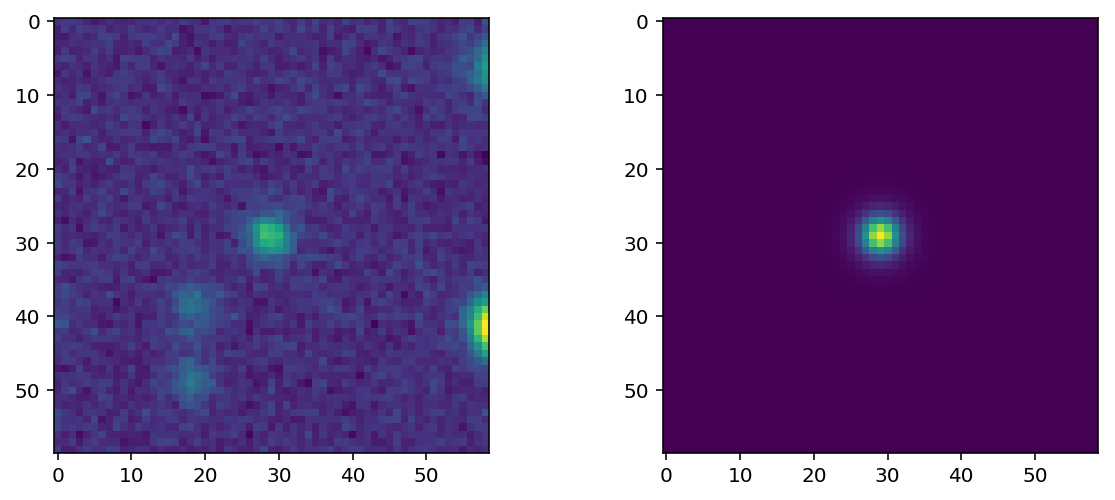

In [203]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].imshow(training_data[0][1,:,:,2])
axes[1].imshow(training_data[1][1,:,:,2])

In [204]:
training_labels.shape

(256, 2)

In [237]:
test = training_generator.__getitem__(3)

training_data = test[0]#[0], test[0][1]]
training_labels = test[1]

In [238]:
def gaussian(mean,std):
    return (1/(std*np.sqrt(2*np.pi))*np.exp(-np.square(x-mean)/(2*std**2)))

x = np.linspace(-1,1, 1000)

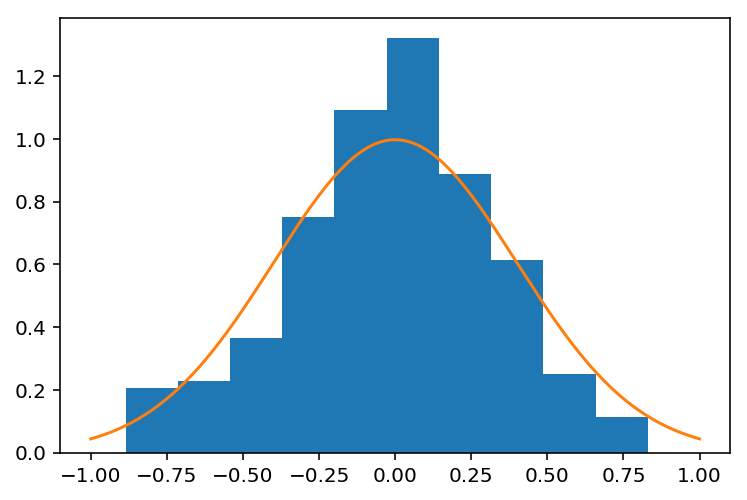

In [239]:
_ = plt.hist(training_labels[:,0], bins = 10, normed = True)
plt.plot(x, gaussian(0,0.4))

In [240]:
import seaborn as sns

mean e2: -0.004983730886085353 mean e2: -0.018939607409653045


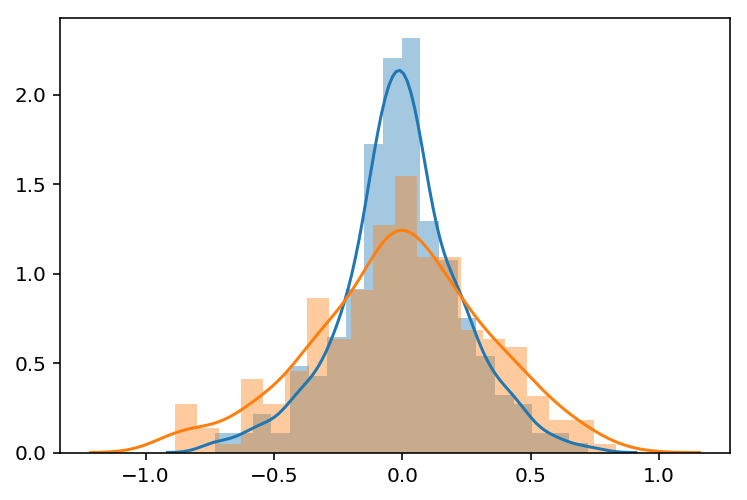

In [241]:
#### Plots
## REGENERER AVEC NOUVELLES IMAGES ET RENORMALISATION CORRECTE
#loading_path = '/sps/lsst/users/barcelin/TFP/weights/test_dc2/'+str(sys.argv[2])+'/loss/'#test_5
#latest = tf.train.latest_checkpoint(loading_path)
#net.load_weights(latest)
#test = test_generator.__getitem__(3)

#training_data = (images_blend[3000:3500],psf[3000:3500])#[0], test[0][1]]
#training_labels = e_test
#print(training_data.shape)
out = param_estim_net([tf.cast(training_data[0], tf.float32), tf.cast(training_data[1], tf.float32)])# net(training_data) en TF2

print('mean e2: '+str(np.mean(K.get_value(out.mean())[:,0]))+' mean e2: '+str(np.mean(K.get_value(out.mean())[:,1])))

#fig, axes = plt.subplots(1,2, figsize = (10,4))
sns.distplot(K.get_value(out.mean())[:,0], bins = 20)# out.mean().numpy()
sns.distplot(training_labels[:,0], bins = 20)
#fig.savefig('full_prob/test_distrib_e1.png')

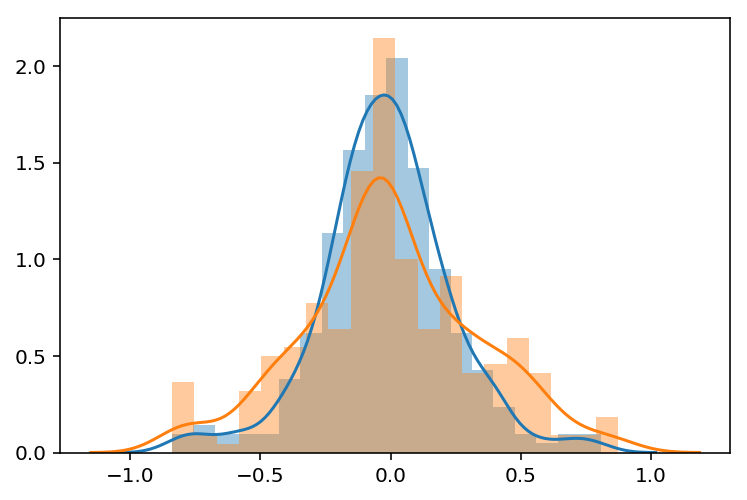

In [242]:
fig = plt.figure()
sns.distplot(K.get_value(out.mean())[:,1], bins = 20)# out.mean().numpy()
sns.distplot(training_labels[:,1], bins = 20)
#fig.savefig('full_prob/test_distrib_e2.png')

Text(0.5, 1.0, '$e2$')

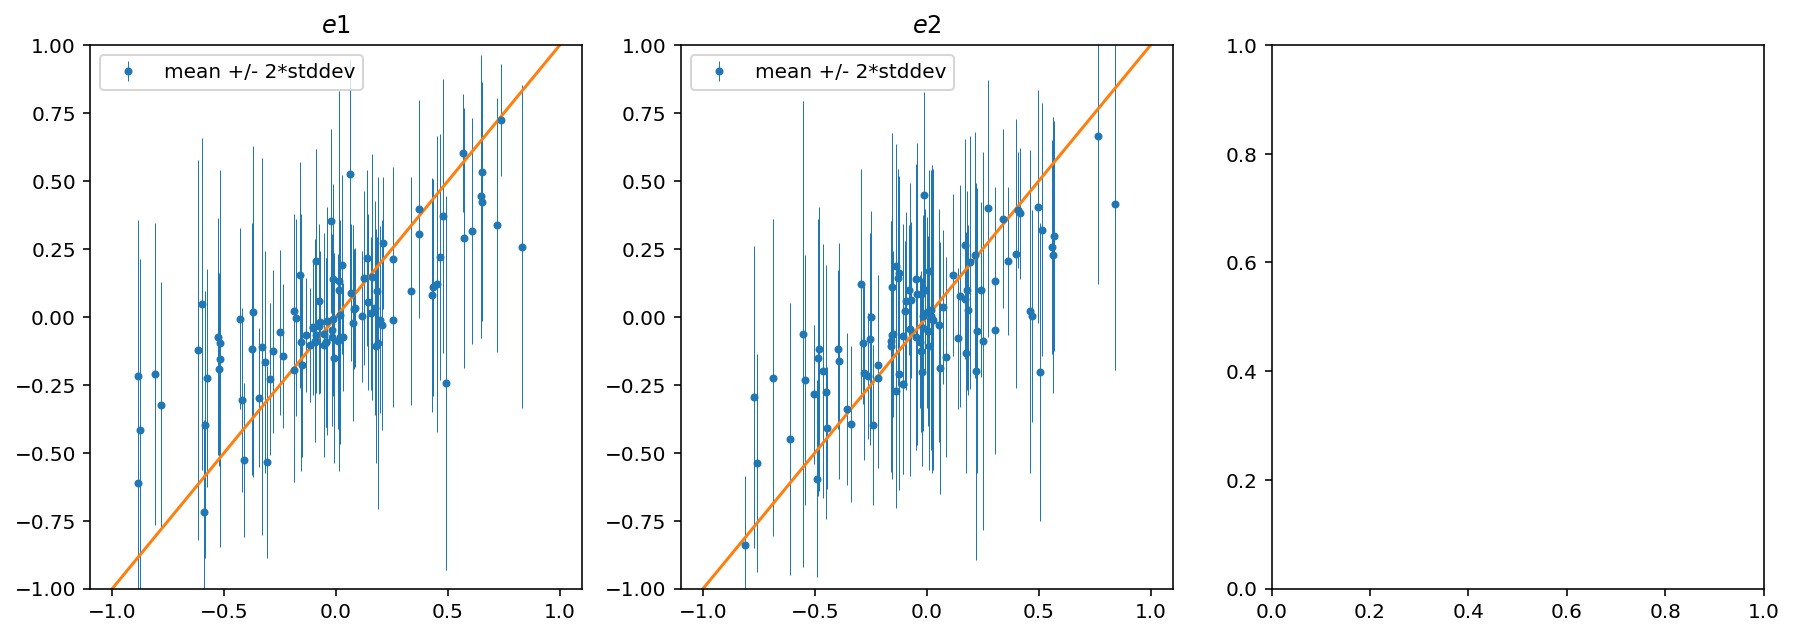

In [243]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

nb_of_points = 100
axes[0].errorbar(training_labels[:nb_of_points,0], K.get_value(out.mean())[:nb_of_points,0], yerr = 2*K.get_value(out.stddev())[:nb_of_points,0],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-1,1)#(-1,1)#-0,5
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)#(-1,1)#-1,1
axes[0].set_title('$e1$')

axes[1].errorbar(training_labels[:nb_of_points,1], K.get_value(out.mean())[:nb_of_points,1], yerr = 2*K.get_value(out.stddev())[:nb_of_points,1],  fmt='.', elinewidth=0.5, label = 'mean +/- 2*stddev')
x = np.linspace(-1,1)#(-1,1)#-1,1
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)#(-1,1)#-1,1
axes[1].set_title('$e2$')

In [244]:
out[:,0]

<tf.Tensor 'strided_slice_15:0' shape=(256,) dtype=float64>

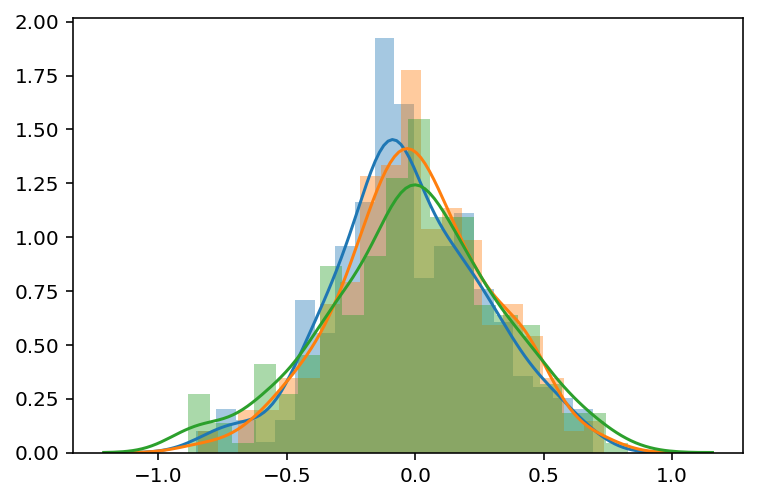

In [247]:
sns.distplot(K.get_value(out[:,0]), bins = 20, label = 'output')
sns.distplot(K.get_value(out[:,0]), bins = 20, label = 'output')
sns.distplot(training_labels[:,0], bins = 20, label = 'input')

Text(0.5, 1.0, '$e2$')

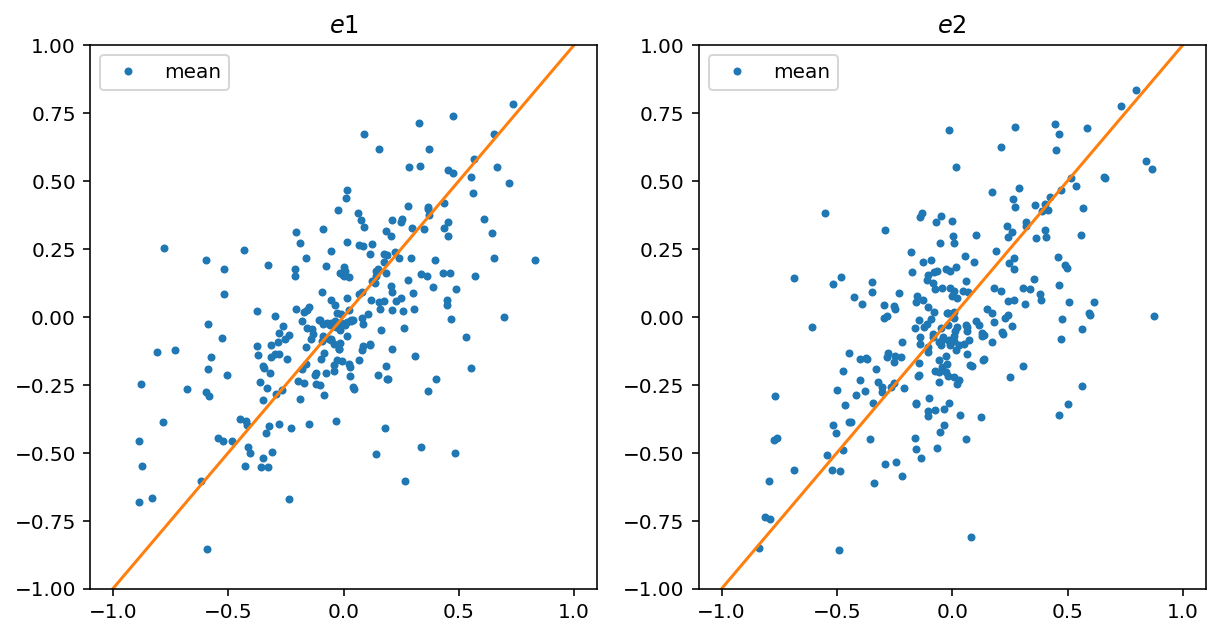

In [246]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(training_labels[:,0], K.get_value(out[:,0]), '.', label = 'mean')
x = np.linspace(-1,1)
axes[0].plot(x, x)
axes[0].legend()
axes[0].set_ylim(-1,1)
axes[0].set_title('$e1$')

axes[1].plot(training_labels[:,1], K.get_value(out[:,1]), '.', label = 'mean')
x = np.linspace(-1,1)
axes[1].plot(x, x)
axes[1].legend()
axes[1].set_ylim(-1,1)
axes[1].set_title('$e2$')

### Test with batch generator to do profiling

In [22]:
import tensorflow

In [23]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

def calc_lensed_ellipticity(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.absolute(e)

In [24]:
class BatchGenerator_dc2_deconv_vae(tensorflow.keras.utils.Sequence):
    """
    Class to create batch generator for the LSST VAE.
    """
    def __init__(self, bands,path, list_of_samples,total_sample_size, batch_size, trainval_or_test, do_norm,denorm, list_of_weights_e):
        """
        Initialization function
        total_sample_size: size of the whole training (or validation) sample
        batch_size: size of the batches to provide
        list_of_samples: list of the numpy arrays which correspond to the whole training (or validation) sample
#        path: path to the first numpy array taken in which the batch will be taken
        training_or_validation: choice between training of validation generator
        x: input of the neural network
        y: target of the neural network
        r: random value to sample into the validation sample
        """
        self.bands = bands
        self.nbands = len(bands)
        self.total_sample_size = total_sample_size
        self.batch_size = batch_size
        self.list_of_samples = list_of_samples
        self.trainval_or_test = trainval_or_test
        self.path = path
        
        self.epoch = 0
        self.do_norm = do_norm
        self.denorm = denorm

        # Weights computed from the lengths of lists
        self.p = []
        for sample in self.list_of_samples:
            temp = np.load(sample, mmap_mode = 'c')
            self.p.append(float(len(temp)))
        self.p = np.array(self.p)
        self.total_sample_size = int(np.sum(self.p))
        print("[BatchGenerator] total_sample_size = ", self.total_sample_size)
        print("[BatchGenerator] len(list_of_samples) = ", len(self.list_of_samples))

        self.p /= np.sum(self.p)

        self.produced_samples = 0
        self.list_of_weights_e = list_of_weights_e
        #self.shifts = shifts

    def __len__(self):
        """
        Function to define the length of an epoch
        """
        return int(float(self.total_sample_size) / float(self.batch_size))      

    def on_epoch_end(self):
        """
        Function executed at the end of each epoch
        """
        # indices = 0
        #print("Produced samples", self.produced_samples)
        self.produced_samples = 0
        
    def __getitem__(self, idx):
        """
        Function which returns the input and target batches for the network
        """
        # If the generator is a training generator, the whole sample is displayed
        sample_filename = np.random.choice(self.list_of_samples, p=self.p)
        #index = np.random.choice(1)
        #index = np.random.choice(list(range(len(self.p))), p=self.p)
        #sample_filename = self.list_of_samples[index]

        sample = np.load(sample_filename, mmap_mode = 'c')
        sample_dc2 = np.load(sample_filename.replace('img_noiseless_sample','img_cropped_sample'), mmap_mode = 'c')
        data = pd.read_csv(sample_filename.replace('img_noiseless_sample','img_noiseless_data').replace('.npy','.csv'))
        psf = np.load(sample_filename.replace('img_noiseless_sample','psf_cropped_sample'), mmap_mode = 'c')
        #print(len(data['e1']))
        data['weights']=(np.abs(data['e1'])+np.abs(data['e2']))
        new_data = data[(np.abs(data['e1'])<=1.) &
                        (np.abs(data['e2'])<=1.)]# &
                        #(data['snr_r']>20)]#snr_r
                        #(np.abs(data['blendedness'])==0.)]# &
        #print(len(new_data['e1']))
        
        if self.list_of_weights_e == None:
            indices = np.random.choice(new_data.index, size=self.batch_size, replace=False, p = new_data['weights']/np.sum(new_data['weights']))
        else:
            self.weights_e = np.load(self.list_of_weights_e[index])
            indices = np.random.choice(new_data.index, size=self.batch_size, replace=False, p = self.weights_e/np.sum(self.weights_e))

        self.produced_samples += len(indices)
        
        ell_1 = np.array(new_data['e1'][indices])
        ell_2 = np.array(new_data['e2'][indices])
        shear_1 = np.array(new_data['shear_1'][indices])
        shear_2 = np.array(new_data['shear_2'][indices])
        convergence = np.array(new_data['convergence'][indices])
        
        ellipticity = calc_lensed_ellipticity(ell_1, ell_2, shear_1, shear_2, convergence)
        ellipticity_conversion = lambda e: 2*e / (1.0+ellipticity[:len(e)]*ellipticity[:len(e)])

        ellipticity_1 = ellipticity_conversion(calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence))
        ellipticity_2 = ellipticity_conversion(calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence))

        x_1 = np.tanh(np.arcsinh(sample_dc2[indices][:,:,:,self.bands]))
        x_3 = np.tanh(np.arcsinh(sample[indices][:,:,:,self.bands]))
        x_2 = psf[indices][:,:,:,self.bands]
        y = np.zeros((self.batch_size, 2))

        #flip : flipping the image array
        rand = np.random.randint(4)
        if rand == 1: 
            x_1 = np.flip(x_1, axis=2)
            x_2 = np.flip(x_2, axis=2)
            x_3 = np.flip(x_3, axis=2)
            y[:,0] = -ellipticity_1
            y[:,1] = -ellipticity_2
        elif rand == 2:
            x_1 = np.swapaxes(x_1, 2, 1)
            x_2 = np.swapaxes(x_2, 2, 1)
            x_3 = np.swapaxes(x_3, 2, 1)
            y[:,0] = +ellipticity_1
            y[:,1] = ellipticity_2
        elif rand == 3:
            x_1 = np.swapaxes(np.flip(x_1, axis=2), 2, 1)
            x_2 = np.swapaxes(np.flip(x_2, axis=2), 2, 1)
            x_3 = np.swapaxes(np.flip(x_3, axis=2), 2, 1)
            y[:,0] = +ellipticity_1
            y[:,1] = -ellipticity_2
        else:
            y[:,0] = -ellipticity_1
            y[:,1] = ellipticity_2
        if len(self.bands)==1:
            x_1 = np.expand_dims(x_1, axis=-1)
            x_2 = np.expand_dims(x_2, axis=-1)
            x_3 = np.expand_dims(x_3, axis=-1)

        #print(y)
        #x_1 = np.arcsinh(x_1/0.01)
        if self.trainval_or_test == 'training' or self.trainval_or_test == 'validation':
            return (x_1, x_2), x_3
        elif self.trainval_or_test == 'test':
            return (x_1, x_2), x_3

In [25]:
def training_batch_generator():
    multi_enqueuer = tf.keras.utils.OrderedEnqueuer(training_generator,
                                                use_multiprocessing=False)
    multi_enqueuer.start(workers=10, max_queue_size=10)
    while True:
        batch_x, batch_y = next(multi_enqueuer.get())
        yield batch_x, batch_y

# Recommended to specify the expected output shapes and types here
output_types = ((tf.float32,tf.float32), tf.float32)
output_shapes = ((tf.TensorShape([batch_size, 59, 59, nb_of_bands]),tf.TensorShape([batch_size, 59, 59, nb_of_bands])),
                tf.TensorShape([batch_size, 59, 59, nb_of_bands]))

training_ds = tf.data.Dataset.from_generator(training_batch_generator,
                                                output_types=output_types,
                                                output_shapes=output_shapes).repeat()

In [26]:
def listdir_fullpath(d):
    return [os.path.join(d, f) for f in os.listdir(d)]

images_dir = '/pbs/home/b/barcelin/sps_link/data/dc2_test/'#1_matching/'#deconv_conv_24.5/

list_of_samples = [x for x in listdir_fullpath(os.path.join(images_dir,'training_24.5_v2/')) if x.startswith(os.path.join(images_dir,'training_24.5_v2/')+'img_noiseless_sample')][:1]

In [27]:
training_generator = BatchGenerator_dc2_deconv_vae(bands,
                                        images_dir,
                                        list_of_samples, 
                                        total_sample_size=None,
                                        batch_size=batch_size, 
                                        trainval_or_test='training',
                                        do_norm=False,
                                        denorm = False,
                                        list_of_weights_e=None)

[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [58]:
hist = net.fit(training_generator, epochs=10,#training_ds
                    steps_per_epoch=int(2000/256),
                    verbose=1,
                    shuffle=True,
                    #callbacks = callbacks,
                    validation_data=training_generator,#validation_ds
                    validation_steps=3)

Epoch 1/10
7/7 [==============================] - 9s 1s/step - loss: 931.8735 - mean_squared_error: 1.6284e-04 - acc: 0.9010 - kl_metric: 0.5503 - val_loss: 979.9635 - val_mean_squared_error: 2.9996e-04 - val_acc: 0.8996 - val_kl_metric: 0.5547
Epoch 2/10
7/7 [==============================] - 9s 1s/step - loss: 905.4892 - mean_squared_error: 1.6364e-04 - acc: 0.9068 - kl_metric: 0.5573 - val_loss: 925.6674 - val_mean_squared_error: 1.4757e-04 - val_acc: 0.9064 - val_kl_metric: 0.5677
Epoch 3/10
7/7 [==============================] - 9s 1s/step - loss: 944.0081 - mean_squared_error: 4.3318e-04 - acc: 0.9078 - kl_metric: 0.5371 - val_loss: 895.6079 - val_mean_squared_error: 2.1731e-04 - val_acc: 0.9021 - val_kl_metric: 0.5214
Epoch 4/10
7/7 [==============================] - 9s 1s/step - loss: 926.9304 - mean_squared_error: 3.4495e-04 - acc: 0.8975 - kl_metric: 0.5410 - val_loss: 862.8560 - val_mean_squared_error: 2.5531e-04 - val_acc: 0.8821 - val_kl_metric: 0.5493
Epoch 5/10
7/7 [====

In [ ]:
hist = net.fit(training_ds, 
                epochs=10,#training_ds
                steps_per_epoch=int(2000/256),
                verbose=1,
                shuffle=True,
                #callbacks = callbacks,
                validation_data=training_ds,#validation_ds
                validation_steps=3)

Train on 7 steps, validate on 3 steps
Epoch 1/10
7/7 [==============================] - 20s 3s/step - loss: 891.1245 - mean_squared_error: 1.2227e-04 - acc: 0.8986 - kl_metric: 0.5566 - val_loss: 935.3646 - val_mean_squared_error: 1.3523e-04 - val_acc: 0.9053 - val_kl_metric: 0.5654
Epoch 2/10
7/7 [==============================] - 11s 2s/step - loss: 881.1509 - mean_squared_error: 1.6199e-04 - acc: 0.9017 - kl_metric: 0.5486 - val_loss: 966.2236 - val_mean_squared_error: 1.6417e-04 - val_acc: 0.9129 - val_kl_metric: 0.5412
Epoch 3/10
7/7 [==============================] - 16s 2s/step - loss: 944.5797 - mean_squared_error: 1.4862e-04 - acc: 0.9026 - kl_metric: 0.5215 - val_loss: 882.8358 - val_mean_squared_error: 1.1276e-04 - val_acc: 0.9030 - val_kl_metric: 0.5245
Epoch 4/10
7/7 [==============================] - 50s 7s/step - loss: 880.8136 - mean_squared_error: 1.1018e-04 - acc: 0.9020 - kl_metric: 0.5330 - val_loss: 913.9451 - val_mean_squared_error: 1.3921e-04 - val_acc: 0.9083 - 

In [48]:
#%%prun -s cumulative -q -l 10 -T test_profile

def main_func():
    net.fit(training_generator, epochs=2,#training_ds
                    steps_per_epoch=int(2000/256),
                    verbose=1,
                    shuffle=True,
                    #callbacks = callbacks,
                    validation_data=training_generator,#validation_ds
                    validation_steps=3)


In [33]:
#c_profile_output = cProfile.run('train_model()')

Epoch 1/10
7/7 [==============================] - 9s 1s/step - loss: 944.9883 - mean_squared_error: 4.7137e-04 - acc: 0.9042 - kl_metric: 0.4594 - val_loss: 975.0542 - val_mean_squared_error: 3.3938e-04 - val_acc: 0.9070 - val_kl_metric: 0.4796
Epoch 2/10
7/7 [==============================] - 8s 1s/step - loss: 918.9803 - mean_squared_error: 2.9022e-04 - acc: 0.9016 - kl_metric: 0.4626 - val_loss: 950.1284 - val_mean_squared_error: 3.3911e-04 - val_acc: 0.9053 - val_kl_metric: 0.4740
Epoch 3/10
7/7 [==============================] - 8s 1s/step - loss: 909.7384 - mean_squared_error: 2.9778e-04 - acc: 0.9044 - kl_metric: 0.4660 - val_loss: 974.2617 - val_mean_squared_error: 5.0285e-04 - val_acc: 0.9073 - val_kl_metric: 0.4862
Epoch 4/10
7/7 [==============================] - 8s 1s/step - loss: 912.0828 - mean_squared_error: 2.7408e-04 - acc: 0.9076 - kl_metric: 0.4859 - val_loss: 924.5932 - val_mean_squared_error: 2.7175e-04 - val_acc: 0.9082 - val_kl_metric: 0.5084
Epoch 5/10
7/7 [====

In [37]:
print(open('test_profile', 'r').read())

         960068 function calls (942385 primitive calls) in 80.408 seconds

   Ordered by: cumulative time
   List reduced from 537 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   80.408   80.408 {built-in method builtins.exec}
        1    0.000    0.000   80.408   80.408 <string>:3(<module>)
        1    0.000    0.000   80.408   80.408 training.py:596(fit)
        1    0.002    0.002   80.408   80.408 training_generator.py:565(fit)
     11/1    0.165    0.015   80.406   80.406 training_generator.py:41(model_iteration)
      100    0.020    0.000   60.093    0.601 backend.py:3529(__call__)
      100    0.003    0.000   56.149    0.561 session.py:1466(__call__)
      100   56.146    0.561   56.146    0.561 {built-in method _pywrap_tensorflow_internal.TF_SessionRunCallable}
       70    0.019    0.000   49.695    0.710 training.py:1025(train_on_batch)
     1778   18.607    0.010   18.607    0.010 {metho

In [38]:
%load_ext snakeviz

The snakeviz extension is already loaded. To reload it, use:
  %reload_ext snakeviz


In [49]:
%snakeviz main_func()

Epoch 1/2
7/7 [==============================] - 43s 6s/step - loss: 903.4462 - mean_squared_error: 2.2524e-04 - acc: 0.9044 - kl_metric: 0.4570 - val_loss: 885.3170 - val_mean_squared_error: 2.0598e-04 - val_acc: 0.9059 - val_kl_metric: 0.4628
Epoch 2/2
7/7 [==============================] - 8s 1s/step - loss: 934.5019 - mean_squared_error: 1.8676e-04 - acc: 0.9003 - kl_metric: 0.4576 - val_loss: 936.7517 - val_mean_squared_error: 2.1530e-04 - val_acc: 0.8991 - val_kl_metric: 0.4702
 
*** Profile stats marshalled to file '/tmp/tmprkzu1klm'. 
Embedding SnakeViz in this document...


In [46]:
#from pyquickhelper.helpgen import NbImage
#NbImage("/tmp/tmpaa39l5d8", width=400)

ModuleNotFoundError: No module named 'pyquickhelper'